# Notebook 3 — Harmonised Full Walk-Forward LightGBM Training and Evaluation on M15

This notebook is the final harmonised LightGBM experiment for the master’s capstone. It replaces the earlier completed LightGBM development run for final cross-model comparison while preserving that earlier run as an archived internal experiment.

The notebook evaluates four tracks on the selected M15 timeframe:

1. vanilla price-only LightGBM
2. vanilla volume-assisted LightGBM
3. tuned price-only LightGBM
4. tuned volume-assisted LightGBM

The final holdout from **2025-01-01 to 2026-03-31 remains untouched**.

## Why this harmonised rerun is required

The final LSTM and CNN-LSTM notebooks use a stricter chronological selection framework. A fair cross-model comparison requires LightGBM to use the same temporal roles:

- inner chronological validation for LightGBM hyperparameter and boosting-iteration selection;
- a separate outer validation year used only for trading-overlay selection;
- one unseen test year per expanding walk-forward fold;
- persistent Optuna studies that retain completed trials after interruption;
- completed fold-track detection and skipping;
- configuration-fingerprint protection against changed parameters on resume;
- identical overlay grid, risk controls and transaction-cost grid to the final deep-learning notebooks;
- explicit calibration, validation-to-test decay and feature-importance diagnostics.

The purpose is **protocol consistency and stronger selection control**, not an attempt to guarantee a better LightGBM result. The revised result must be accepted even if it is worse than the archived development run.


## Methodological justification and research references

### Why LightGBM

LightGBM is an efficient gradient-boosted decision-tree framework. Its leaf-wise growth can fit complex nonlinear interactions in tabular features, but that flexibility also requires explicit complexity and regularisation controls. It remains the capstone benchmark against the sequential LSTM and CNN-LSTM models.

### Why the revised chronological validation framework

The earlier LightGBM notebook used the same validation year for hyperparameter selection and trading-overlay selection. That design did not expose the subsequent test year, but model parameters, boosting iterations and overlay rules are all adaptive choices. Repeated optimisation against one period increases the chance of selecting period-specific noise.

The harmonised notebook therefore uses two ordered validation roles inside every outer fold:

1. the last year inside the outer training history is used for LightGBM hyperparameter and boosting-iteration selection;
2. the following outer validation year is used only for overlay selection;
3. the next year is evaluated once as the unseen test window.

This is a conservative nested chronological design. It reduces reuse of one period for multiple selection stages while preserving temporal order. It does not guarantee better prediction or trading returns.

### Why expanding walk-forward evaluation

Financial time series can be non-stationary. The notebook retains expanding historical training windows and multiple unseen annual test periods rather than shuffled cross-validation.

### Why bounded full Optuna tuning

Optuna TPE searches the principal LightGBM capacity, sampling, regularisation and optimisation parameters. The search budget is fixed before viewing the harmonised result. LightGBM trials are substantially cheaper than neural-network trials, so **150 trials per tuned track per fold** are retained for a thorough search. Persistent SQLite storage allows completed trials to survive Colab interruptions.

### Why these LightGBM parameters are tuned

- `num_leaves` and `max_depth` control leaf-wise tree complexity.
- `min_child_samples` and `min_child_weight` prevent overly small or weakly supported leaves.
- `feature_fraction` and `bagging_fraction` introduce stochastic subsampling that can reduce overfitting.
- `lambda_l1`, `lambda_l2` and `min_gain_to_split` regularise tree construction.
- `learning_rate` and the validation-selected boosting iteration control the shrinkage/capacity trade-off.
- `max_bin` changes histogram granularity and can affect both accuracy and regularisation.

### Why probability diagnostics remain necessary

ROC-AUC measures ranking, not probability calibration. Brier score and log loss are therefore compared with a training-prevalence baseline, although architecture selection remains based on inner-validation ROC-AUC for consistency with the neural notebooks.

### Primary and authoritative references

1. Ke, G. et al. (2017). **LightGBM: A Highly Efficient Gradient Boosting Decision Tree.** *NeurIPS 30*. https://proceedings.neurips.cc/paper/6907-lightgbm-a-highly-efficient-gradient-boosting-decision-tree
2. LightGBM Developers. **Parameters Tuning.** https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
3. Cawley, G. C., & Talbot, N. L. C. (2010). **On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation.** *JMLR, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html
4. Cerqueira, V., Torgo, L., & Mozetič, I. (2020). **Evaluating Time Series Forecasting Models: An Empirical Study on Performance Estimation Methods.** *Machine Learning, 109*, 1997–2028. https://doi.org/10.1007/s10994-020-05910-7
5. Tashman, L. J. (2000). **Out-of-sample Tests of Forecasting Accuracy: An Analysis and Review.** *International Journal of Forecasting, 16*(4), 437–450. https://doi.org/10.1016/S0169-2070(00)00065-0
6. Akiba, T. et al. (2019). **Optuna: A Next-generation Hyperparameter Optimization Framework.** KDD. https://doi.org/10.1145/3292500.3330701
7. Bailey, D. H. et al. (2016). **The Probability of Backtest Overfitting.** *Journal of Computational Finance, 20*(4), 39–69. https://doi.org/10.21314/JCF.2016.322


## 1. Colab setup

CPU is recommended for this LightGBM notebook. A GPU runtime is not required. LightGBM uses all available CPU threads inside each model, while Optuna runs one trial at a time for reproducibility and SQLite safety.


In [1]:
import importlib.util
import subprocess
import sys

for package_name, pip_name in [
    ("lightgbm", "lightgbm>=4.3,<5"),
    ("optuna", "optuna>=4.1,<5"),
    ("joblib", "joblib"),
    ("pyarrow", "pyarrow"),
]:
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


Installing optuna>=4.1,<5...


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Any

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display
from optuna.trial import TrialState
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
)

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('LightGBM:', lgb.__version__)
print('Optuna:', optuna.__version__)


Mounted at /content/drive
LightGBM: 4.6.0
Optuna: 4.9.0


In [3]:
# ============================
# User-adjustable configuration
# ============================

NOTEBOOK_CONFIG_VERSION = '03_lightgbm_harmonised_nested_resume_v1_2026-06-14'
PROJECT_ROOT = Path('/content/drive/MyDrive/fyp_master_starter') if IN_COLAB else Path('.').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'capstone_methodology'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_DIR = DATA_DIR / 'notebook_outputs' / '03_m15_lightgbm_walkforward_full_harmonised'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'
PREPROCESSING_DIR = OUTPUT_DIR / 'preprocessing'
OPTUNA_DIR = OUTPUT_DIR / 'optuna_studies'
CONFIG_DIR = OUTPUT_DIR / 'configuration'

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR, PREPROCESSING_DIR, OPTUNA_DIR, CONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PRICE_ONLY_PATH = PROCESSED_DIR / 'dukascopy_xauusd_m15_price_only_relative_dataset.parquet'
VOLUME_ASSISTED_PATH = PROCESSED_DIR / 'dukascopy_xauusd_m15_volume_assisted_relative_dataset.parquet'
INTEGRITY_SUMMARY_PATH = DATA_DIR / 'reports' / 'data_quality' / 'dukascopy_xauusd_m5_m15_relative_pipeline_integrity_summary.json'

FINAL_HOLDOUT_START = pd.Timestamp('2025-01-01', tz='UTC')
BAR_MINUTES = 15
EXPECTED_BAR_DELTA = pd.Timedelta(minutes=BAR_MINUTES)
INNER_VALIDATION_YEARS = 1
RUN_ONLY_UNFINISHED = True
ALLOW_CONFIG_MISMATCH = False

FOLDS = [
    {
        'fold': 1,
        'train_end': pd.Timestamp('2021-01-01', tz='UTC'),
        'validation_start': pd.Timestamp('2021-01-01', tz='UTC'),
        'validation_end': pd.Timestamp('2022-01-01', tz='UTC'),
        'test_start': pd.Timestamp('2022-01-01', tz='UTC'),
        'test_end': pd.Timestamp('2023-01-01', tz='UTC'),
    },
    {
        'fold': 2,
        'train_end': pd.Timestamp('2022-01-01', tz='UTC'),
        'validation_start': pd.Timestamp('2022-01-01', tz='UTC'),
        'validation_end': pd.Timestamp('2023-01-01', tz='UTC'),
        'test_start': pd.Timestamp('2023-01-01', tz='UTC'),
        'test_end': pd.Timestamp('2024-01-01', tz='UTC'),
    },
    {
        'fold': 3,
        'train_end': pd.Timestamp('2023-01-01', tz='UTC'),
        'validation_start': pd.Timestamp('2023-01-01', tz='UTC'),
        'validation_end': pd.Timestamp('2024-01-01', tz='UTC'),
        'test_start': pd.Timestamp('2024-01-01', tz='UTC'),
        'test_end': pd.Timestamp('2025-01-01', tz='UTC'),
    },
]

TARGET_COLUMNS = {'target_ret_fwd', 'target_dir', 'target_class_3'}
CLASSIFICATION_THRESHOLD = 0.5

LIGHTGBM_ARCHITECTURE_VERSION = 'lightgbm_leafwise_gbdt_nested_v1'
MAX_BOOST_ROUNDS = 5000
EARLY_STOPPING_ROUNDS = 200
TUNED_N_TRIALS = 150
OPTUNA_N_JOBS = 1
LIGHTGBM_N_JOBS = max(1, min(8, os.cpu_count() or 1))
PRUNER_STARTUP_TRIALS = 15
PRUNER_WARMUP_BOOST_ROUNDS = 100

VANILLA_PARAMS = {
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 200,
    'min_child_weight': 1e-3,
    'feature_fraction': 0.80,
    'bagging_fraction': 0.80,
    'bagging_freq': 1,
    'lambda_l1': 0.0,
    'lambda_l2': 1.0,
    'min_gain_to_split': 0.0,
    'max_bin': 255,
}

TUNING_SEARCH_SPACE = {
    'learning_rate_min': 0.005,
    'learning_rate_max': 0.10,
    'num_leaves_min': 8,
    'num_leaves_max': 128,
    'max_depth': [-1, 3, 4, 5, 6, 8, 10, 12],
    'min_child_samples_min': 50,
    'min_child_samples_max': 2000,
    'min_child_weight_min': 1e-4,
    'min_child_weight_max': 10.0,
    'feature_fraction_min': 0.50,
    'feature_fraction_max': 1.00,
    'bagging_fraction_min': 0.50,
    'bagging_fraction_max': 1.00,
    'lambda_l1_min': 1e-8,
    'lambda_l1_max': 50.0,
    'lambda_l2_min': 1e-8,
    'lambda_l2_max': 100.0,
    'min_gain_to_split_min': 0.0,
    'min_gain_to_split_max': 0.50,
    'max_bin': [63, 127, 255],
}

MAIN_SELECTION_COST_BPS = 1.0
COST_GRID_BPS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
THRESHOLD_GRID = [(0.51, 0.49), (0.52, 0.48), (0.53, 0.47), (0.55, 0.45)]
MIN_HOLD_GRID = [1, 2, 3]
MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID = [3, 5, 8]
DAILY_LOSS_STOP = -0.02
TOTAL_DRAWDOWN_STOP = -0.15
MIN_VALIDATION_TRADES = 20

FAST_DEBUG = False
if FAST_DEBUG:
    TUNED_N_TRIALS = 5
    MAX_BOOST_ROUNDS = 300
    EARLY_STOPPING_ROUNDS = 30

print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Tuned trials per tuned track per fold:', TUNED_N_TRIALS)
print('Inner validation years:', INNER_VALIDATION_YEARS)


Project root: /content/drive/MyDrive/fyp_master_starter
Output directory: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/03_m15_lightgbm_walkforward_full_harmonised
Tuned trials per tuned track per fold: 150
Inner validation years: 1


In [4]:
def json_ready(value: Any) -> Any:
    if isinstance(value, (pd.Timestamp, Path, pd.Timedelta)):
        return str(value)
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value

critical_config = {
    'notebook_config_version': NOTEBOOK_CONFIG_VERSION,
    'folds': FOLDS,
    'inner_validation_years': INNER_VALIDATION_YEARS,
    'vanilla_params': VANILLA_PARAMS,
    'lightgbm_architecture_version': LIGHTGBM_ARCHITECTURE_VERSION,
    'tuning_search_space': TUNING_SEARCH_SPACE,
    'max_boost_rounds': MAX_BOOST_ROUNDS,
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    'tuned_n_trials': TUNED_N_TRIALS,
    'lightgbm_n_jobs': LIGHTGBM_N_JOBS,
    'pruner_startup_trials': PRUNER_STARTUP_TRIALS,
    'pruner_warmup_boost_rounds': PRUNER_WARMUP_BOOST_ROUNDS,
    'main_selection_cost_bps': MAIN_SELECTION_COST_BPS,
    'cost_grid_bps': COST_GRID_BPS,
    'threshold_grid': THRESHOLD_GRID,
    'min_hold_grid': MIN_HOLD_GRID,
    'max_position_change_events_per_day_grid': MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID,
    'daily_loss_stop': DAILY_LOSS_STOP,
    'total_drawdown_stop': TOTAL_DRAWDOWN_STOP,
    'min_validation_trades': MIN_VALIDATION_TRADES,
    'fast_debug': FAST_DEBUG,
}
config_payload = json.dumps(json_ready(critical_config), sort_keys=True, indent=2)
config_fingerprint = hashlib.sha256(config_payload.encode('utf-8')).hexdigest()
config_path = CONFIG_DIR / 'run_config.json'

if config_path.exists():
    existing = json.loads(config_path.read_text(encoding='utf-8'))
    old_fingerprint = existing.get('config_fingerprint')
    if old_fingerprint != config_fingerprint and not ALLOW_CONFIG_MISMATCH:
        raise RuntimeError(
            'Saved harmonised Notebook 3 configuration does not match the current configuration. '
            'Do not resume with changed parameters. Use a new output folder or explicitly review the difference.'
        )
else:
    config_path.write_text(
        json.dumps({
            'config_fingerprint': config_fingerprint,
            'critical_config': json_ready(critical_config),
        }, indent=2),
        encoding='utf-8',
    )

print('Configuration fingerprint:', config_fingerprint)
print('Configuration file:', config_path)


Configuration fingerprint: 5bf38ebc705299d479c013c7351fc1252268cbaabeea5a4945a7a3a6b2de2ef9
Configuration file: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/03_m15_lightgbm_walkforward_full_harmonised/configuration/run_config.json


## 2. Integrity gate, data loading and temporal roles

For each outer fold:

- the final year inside the outer training period is the **inner model-tuning validation window**;
- the next year is the **outer validation window used only for overlay selection**;
- the following year is the **unseen test window**.

The final 2025–2026 holdout remains untouched.


In [5]:
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing dataset: {path}')
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'time' not in df.columns:
            raise ValueError(f'{path} has no DatetimeIndex or time column.')
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.set_index('time')
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = 'time'
    return df.sort_index()

if not INTEGRITY_SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing integrity summary: {INTEGRITY_SUMMARY_PATH}')

integrity = json.loads(INTEGRITY_SUMMARY_PATH.read_text(encoding='utf-8'))
if integrity.get('final_status') != 'PASS':
    raise RuntimeError(f'Pipeline integrity is not PASS: {integrity}')

price_only = load_dataset(PRICE_ONLY_PATH)
volume_assisted = load_dataset(VOLUME_ASSISTED_PATH)

if not price_only.index.equals(volume_assisted.index):
    raise ValueError('Price-only and volume-assisted datasets are not timestamp-aligned.')
if price_only.index.max() < FINAL_HOLDOUT_START:
    raise ValueError('Expected final holdout is not present in the dataset.')

print('Final holdout exists and remains untouched:', FINAL_HOLDOUT_START, 'to', price_only.index.max())
print('Price-only:', price_only.shape, price_only.index.min(), '->', price_only.index.max())
print('Volume-assisted:', volume_assisted.shape, volume_assisted.index.min(), '->', volume_assisted.index.max())


Final holdout exists and remains untouched: 2025-01-01 00:00:00+00:00 to 2026-03-31 23:45:00+00:00
Price-only: (237001, 53) 2016-01-06 03:15:00+00:00 -> 2026-03-31 23:45:00+00:00
Volume-assisted: (237001, 54) 2016-01-06 03:15:00+00:00 -> 2026-03-31 23:45:00+00:00


In [6]:
def get_feature_columns(df: pd.DataFrame) -> list[str]:
    return [column for column in df.columns if column not in TARGET_COLUMNS]

FEATURE_SETS = {
    'price_only': price_only,
    'volume_assisted': volume_assisted,
}

TRACKS = [
    {'track': 'vanilla_price_only', 'feature_set': 'price_only', 'mode': 'vanilla'},
    {'track': 'vanilla_volume_assisted', 'feature_set': 'volume_assisted', 'mode': 'vanilla'},
    {'track': 'tuned_price_only', 'feature_set': 'price_only', 'mode': 'tuned'},
    {'track': 'tuned_volume_assisted', 'feature_set': 'volume_assisted', 'mode': 'tuned'},
]

fold_rows = []
temporal_roles = []
for feature_set_name, df in FEATURE_SETS.items():
    for fold_def in FOLDS:
        fold = fold_def['fold']
        inner_validation_start = fold_def['train_end'] - pd.DateOffset(years=INNER_VALIDATION_YEARS)
        outer_train = df.loc[df.index < fold_def['train_end']]
        inner_train = outer_train.loc[outer_train.index < inner_validation_start]
        inner_validation = outer_train.loc[outer_train.index >= inner_validation_start]
        outer_validation = df.loc[(df.index >= fold_def['validation_start']) & (df.index < fold_def['validation_end'])]
        test = df.loc[(df.index >= fold_def['test_start']) & (df.index < fold_def['test_end'])]
        fold_rows.append({
            'model_family': 'lightgbm',
            'feature_set': feature_set_name,
            'fold': fold,
            'inner_train_rows': len(inner_train),
            'inner_validation_rows': len(inner_validation),
            'outer_train_rows': len(outer_train),
            'outer_validation_rows': len(outer_validation),
            'test_rows': len(test),
            'inner_validation_start': str(inner_validation_start),
            'outer_train_end': str(outer_train.index.max()),
            'outer_validation_start': str(outer_validation.index.min()),
            'outer_validation_end': str(outer_validation.index.max()),
            'test_start': str(test.index.min()),
            'test_end': str(test.index.max()),
            'feature_count': len(get_feature_columns(df)),
        })
        temporal_roles.extend([
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'inner_model_tuning_train', 'start': str(inner_train.index.min()), 'end': str(inner_train.index.max()), 'rows': len(inner_train)},
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'inner_model_tuning_validation', 'start': str(inner_validation.index.min()), 'end': str(inner_validation.index.max()), 'rows': len(inner_validation)},
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'outer_overlay_validation', 'start': str(outer_validation.index.min()), 'end': str(outer_validation.index.max()), 'rows': len(outer_validation)},
            {'feature_set': feature_set_name, 'fold': fold, 'role': 'unseen_test', 'start': str(test.index.min()), 'end': str(test.index.max()), 'rows': len(test)},
        ])

fold_rows_df = pd.DataFrame(fold_rows)
temporal_roles_df = pd.DataFrame(temporal_roles)
fold_rows_df.to_csv(TABLE_DIR / 'fold_rows_m15_lightgbm.csv', index=False)
temporal_roles_df.to_csv(TABLE_DIR / 'temporal_role_summary.csv', index=False)
display(fold_rows_df)


,model_family,feature_set,fold,inner_train_rows,inner_validation_rows,outer_train_rows,outer_validation_rows,test_rows,inner_validation_start,outer_train_end,outer_validation_start,outer_validation_end,test_start,test_end,feature_count
0,lightgbm,price_only,1,91668,23327,114995,23314,23290,2020-01-01 00:00:00+00:00,2020-12-31 21:45:00+00:00,2021-01-03 23:15:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,50
1,lightgbm,price_only,2,114995,23314,138309,23290,22985,2021-01-01 00:00:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,50
2,lightgbm,price_only,3,138309,23290,161599,22985,23382,2022-01-01 00:00:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,2024-01-01 23:15:00+00:00,2024-12-31 21:30:00+00:00,50
3,lightgbm,volume_assisted,1,91668,23327,114995,23314,23290,2020-01-01 00:00:00+00:00,2020-12-31 21:45:00+00:00,2021-01-03 23:15:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,51
4,lightgbm,volume_assisted,2,114995,23314,138309,23290,22985,2021-01-01 00:00:00+00:00,2021-12-31 21:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,51
5,lightgbm,volume_assisted,3,138309,23290,161599,22985,23382,2022-01-01 00:00:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,2024-01-01 23:15:00+00:00,2024-12-31 21:30:00+00:00,51


## 3. LightGBM model, tuning and probability diagnostics

LightGBM receives each M15 row as a tabular observation. Unlike LSTM/CNN-LSTM, it does not consume rolling sequences, so sequence-window gap exclusion is not applicable. Market-gap awareness remains available through the prepared `is_after_gap` feature, and the trading overlay closes positions at non-contiguous timestamps.

The inner validation period selects hyperparameters and the number of boosting iterations. The selected configuration is then refitted on the complete outer training history before outer-validation overlay selection and unseen test evaluation.


In [7]:
def stable_seed(track: str, fold: int, offset: int = 0) -> int:
    stable_track_value = sum((i + 1) * ord(ch) for i, ch in enumerate(track))
    return int(SEED + stable_track_value + fold * 10_000 + offset)


def classification_metrics(y_true: np.ndarray, p_up: np.ndarray, baseline_p: float) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=int)
    p_up = np.asarray(p_up, dtype=float)
    y_pred = (p_up >= CLASSIFICATION_THRESHOLD).astype(int)
    clipped = np.clip(p_up, 1e-6, 1 - 1e-6)
    baseline_probs = np.full(len(y_true), np.clip(baseline_p, 1e-6, 1 - 1e-6), dtype=float)
    metrics = {
        'roc_auc': float(roc_auc_score(y_true, p_up)) if len(np.unique(y_true)) == 2 else np.nan,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'brier': float(brier_score_loss(y_true, p_up)),
        'baseline_brier': float(brier_score_loss(y_true, baseline_probs)),
        'log_loss': float(log_loss(y_true, clipped)),
        'baseline_log_loss': float(log_loss(y_true, baseline_probs)),
    }
    metrics['brier_improvement_vs_baseline'] = metrics['baseline_brier'] - metrics['brier']
    metrics['log_loss_improvement_vs_baseline'] = metrics['baseline_log_loss'] - metrics['log_loss']
    return metrics


def base_lgbm_params(seed: int) -> dict[str, Any]:
    return {
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'n_estimators': int(MAX_BOOST_ROUNDS),
        'random_state': int(seed),
        'data_random_seed': int(seed),
        'feature_fraction_seed': int(seed),
        'bagging_seed': int(seed),
        'drop_seed': int(seed),
        'deterministic': True,
        'force_col_wise': True,
        'n_jobs': int(LIGHTGBM_N_JOBS),
        'verbosity': -1,
        'metric': 'auc',
    }


def resolved_params(model_params: dict[str, Any], seed: int, n_estimators: int | None = None) -> dict[str, Any]:
    params = base_lgbm_params(seed)
    params.update(model_params)
    if n_estimators is not None:
        params['n_estimators'] = int(max(1, n_estimators))
    return params


def sample_lgbm_params(trial: optuna.Trial) -> dict[str, Any]:
    s = TUNING_SEARCH_SPACE
    return {
        'learning_rate': float(trial.suggest_float('learning_rate', s['learning_rate_min'], s['learning_rate_max'], log=True)),
        'num_leaves': int(trial.suggest_int('num_leaves', s['num_leaves_min'], s['num_leaves_max'], log=True)),
        'max_depth': int(trial.suggest_categorical('max_depth', s['max_depth'])),
        'min_child_samples': int(trial.suggest_int('min_child_samples', s['min_child_samples_min'], s['min_child_samples_max'], log=True)),
        'min_child_weight': float(trial.suggest_float('min_child_weight', s['min_child_weight_min'], s['min_child_weight_max'], log=True)),
        'feature_fraction': float(trial.suggest_float('feature_fraction', s['feature_fraction_min'], s['feature_fraction_max'])),
        'bagging_fraction': float(trial.suggest_float('bagging_fraction', s['bagging_fraction_min'], s['bagging_fraction_max'])),
        'bagging_freq': 1,
        'lambda_l1': float(trial.suggest_float('lambda_l1', s['lambda_l1_min'], s['lambda_l1_max'], log=True)),
        'lambda_l2': float(trial.suggest_float('lambda_l2', s['lambda_l2_min'], s['lambda_l2_max'], log=True)),
        'min_gain_to_split': float(trial.suggest_float('min_gain_to_split', s['min_gain_to_split_min'], s['min_gain_to_split_max'])),
        'max_bin': int(trial.suggest_categorical('max_bin', s['max_bin'])),
    }


def make_lgbm_pruning_callback(trial: optuna.Trial):
    def _callback(env):
        for result in env.evaluation_result_list:
            if len(result) < 3:
                continue
            data_name, metric_name, metric_value = result[:3]
            if data_name == 'valid_0' and metric_name == 'auc':
                trial.report(float(metric_value), step=int(env.iteration))
                if env.iteration >= PRUNER_WARMUP_BOOST_ROUNDS and trial.should_prune():
                    raise optuna.TrialPruned(
                        f'Pruned at boosting iteration {env.iteration + 1} with validation AUC={metric_value:.6f}'
                    )
                break
    _callback.order = 30
    _callback.before_iteration = False
    return _callback


def fit_inner_lgbm(
    inner_train_df: pd.DataFrame,
    inner_validation_df: pd.DataFrame,
    feature_columns: list[str],
    model_params: dict[str, Any],
    seed: int,
    trial: optuna.Trial | None = None,
) -> tuple[lgb.LGBMClassifier, pd.DataFrame, dict[str, Any]]:
    X_train = inner_train_df[feature_columns]
    y_train = inner_train_df['target_dir'].astype(int)
    X_validation = inner_validation_df[feature_columns]
    y_validation = inner_validation_df['target_dir'].astype(int)
    model = lgb.LGBMClassifier(**resolved_params(model_params, seed))
    callbacks = [
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=False),
        lgb.log_evaluation(period=0),
    ]
    if trial is not None:
        callbacks.append(make_lgbm_pruning_callback(trial))
    start_time = time.time()
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_validation, y_validation)],
        eval_metric='auc',
        callbacks=callbacks,
    )
    elapsed = time.time() - start_time
    p_validation = model.predict_proba(X_validation, num_iteration=model.best_iteration_)[:, 1]
    baseline_p = float(y_train.mean())
    metrics = classification_metrics(y_validation.to_numpy(), p_validation, baseline_p)
    best_iteration = int(model.best_iteration_ or model.n_estimators_ or MAX_BOOST_ROUNDS)
    evals_result = model.evals_result_.get('valid_0', {})
    history_length = max((len(v) for v in evals_result.values()), default=0)
    history_df = pd.DataFrame({'boosting_iteration': np.arange(1, history_length + 1)})
    for metric_name, values in evals_result.items():
        history_df[metric_name] = values
    info = {
        'best_iteration': best_iteration,
        'best_inner_validation_auc': float(metrics['roc_auc']),
        'best_inner_validation_brier': float(metrics['brier']),
        'best_inner_validation_log_loss': float(metrics['log_loss']),
        'boosting_iterations_trained': int(history_length),
        'inner_training_seconds': float(elapsed),
    }
    return model, history_df, info


def fit_final_lgbm(
    outer_train_df: pd.DataFrame,
    feature_columns: list[str],
    model_params: dict[str, Any],
    best_iteration: int,
    seed: int,
) -> tuple[lgb.LGBMClassifier, dict[str, Any]]:
    model = lgb.LGBMClassifier(**resolved_params(model_params, seed, n_estimators=best_iteration))
    start_time = time.time()
    model.fit(
        outer_train_df[feature_columns],
        outer_train_df['target_dir'].astype(int),
        callbacks=[lgb.log_evaluation(period=0)],
    )
    elapsed = time.time() - start_time
    return model, {
        'final_n_estimators': int(best_iteration),
        'final_training_seconds': float(elapsed),
        'outer_train_rows': int(len(outer_train_df)),
        'model_tree_count': int(model.booster_.num_trees()),
    }


## 4. Trading overlay

This is the same validation-only overlay and risk policy used by the final harmonised LSTM and CNN-LSTM notebooks. The overlay is part of the full trading system, but it is not allowed to use the unseen test window for selection.


In [8]:
def max_drawdown_from_log_returns(log_returns: np.ndarray) -> float:
    if len(log_returns) == 0:
        return 0.0
    equity = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(equity)
    drawdown = equity / peak - 1.0
    return float(drawdown.min()) if len(drawdown) else 0.0


def sortino_ratio(log_returns: np.ndarray, periods_per_year: float) -> float:
    if len(log_returns) < 2:
        return 0.0
    downside = log_returns[log_returns < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return 0.0
    return float(log_returns.mean() / downside.std(ddof=1) * math.sqrt(periods_per_year))


def profit_factor(log_returns: np.ndarray) -> float:
    gains = log_returns[log_returns > 0].sum()
    losses = -log_returns[log_returns < 0].sum()
    if losses == 0:
        return float('inf') if gains > 0 else 0.0
    return float(gains / losses)


def apply_signal_overlay(
    timestamps: pd.DatetimeIndex,
    p_up: np.ndarray,
    forward_log_returns: np.ndarray,
    upper_threshold: float,
    lower_threshold: float,
    min_hold_bars: int,
    max_position_change_events_per_day: int,
    cost_bps: float,
    expected_delta: pd.Timedelta = EXPECTED_BAR_DELTA,
    daily_loss_stop: float = DAILY_LOSS_STOP,
    total_drawdown_stop: float = TOTAL_DRAWDOWN_STOP,
) -> dict[str, Any]:
    timestamps = pd.DatetimeIndex(timestamps)
    desired = np.where(p_up >= upper_threshold, 1, np.where(p_up <= lower_threshold, -1, 0)).astype(int)

    positions = np.zeros(len(desired), dtype=int)
    log_rets = np.zeros(len(desired), dtype=float)
    costs = np.zeros(len(desired), dtype=float)
    position_change_events = 0
    turnover_units = 0.0
    trades = 0
    stopped_by_total_dd = False
    daily_stop_active = False
    current_day = None
    daily_log_sum = 0.0
    bars_since_change = 10**9
    prev_pos = 0
    equity_log = 0.0
    peak_equity = 1.0
    total_dd_stop_triggered = False
    daily_loss_stop_triggered_count = 0

    for i, ts in enumerate(timestamps):
        day = ts.date()
        if current_day != day:
            current_day = day
            daily_log_sum = 0.0
            daily_stop_active = False
            day_position_change_events = 0

        is_gap = False
        if i > 0 and (timestamps[i] - timestamps[i - 1]) != expected_delta:
            is_gap = True

        if stopped_by_total_dd:
            new_pos = 0
        elif is_gap:
            new_pos = 0
            bars_since_change = 10**9
        elif daily_stop_active:
            new_pos = 0
        else:
            proposed = desired[i]
            can_change_due_to_hold = bars_since_change >= min_hold_bars
            if proposed != prev_pos and can_change_due_to_hold:
                if day_position_change_events < max_position_change_events_per_day:
                    new_pos = proposed
                    day_position_change_events += 1
                    position_change_events += 1
                    bars_since_change = 0
                else:
                    new_pos = prev_pos
            else:
                new_pos = prev_pos

        turnover = abs(new_pos - prev_pos)
        cost = (cost_bps / 10000.0) * turnover
        gross = new_pos * forward_log_returns[i]
        net = gross - cost

        positions[i] = new_pos
        costs[i] = cost
        log_rets[i] = net
        turnover_units += turnover
        if turnover > 0 and new_pos != 0:
            trades += 1

        equity_log += net
        equity = math.exp(equity_log)
        peak_equity = max(peak_equity, equity)
        drawdown = equity / peak_equity - 1.0
        daily_log_sum += net

        if daily_log_sum <= math.log(1 + daily_loss_stop) and not daily_stop_active:
            daily_stop_active = True
            daily_loss_stop_triggered_count += 1

        if drawdown <= total_drawdown_stop and not stopped_by_total_dd:
            stopped_by_total_dd = True
            total_dd_stop_triggered = True

        if new_pos == prev_pos:
            bars_since_change += 1
        prev_pos = new_pos

    periods_per_year = (24 * 60 / BAR_MINUTES) * 252
    total_net_return = float(math.exp(log_rets.sum()) - 1.0)
    total_gross_return = float(math.exp((positions * forward_log_returns).sum()) - 1.0)
    mean_ret = log_rets.mean() if len(log_rets) else 0.0
    std_ret = log_rets.std(ddof=1) if len(log_rets) > 1 else 0.0
    sharpe = float(mean_ret / std_ret * math.sqrt(periods_per_year)) if std_ret > 0 else 0.0
    sortino = sortino_ratio(log_rets, periods_per_year)
    max_dd = max_drawdown_from_log_returns(log_rets)
    active_rate = float(np.mean(positions != 0)) if len(positions) else 0.0
    win_rate = float(np.mean(log_rets[log_rets != 0] > 0)) if np.any(log_rets != 0) else 0.0
    pf = profit_factor(log_rets)
    days = max((timestamps.max() - timestamps.min()).days, 1) if len(timestamps) else 1

    return {
        'net_return': total_net_return,
        'gross_return': total_gross_return,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_dd,
        'turnover_units': float(turnover_units),
        'turnover_units_per_day': float(turnover_units / days),
        'position_change_events': int(position_change_events),
        'position_change_events_per_day': float(position_change_events / days),
        'trade_count': int(trades),
        'active_rate': active_rate,
        'win_rate': win_rate,
        'profit_factor': pf,
        'daily_loss_stop_triggered_count': int(daily_loss_stop_triggered_count),
        'total_drawdown_stop_triggered': bool(total_dd_stop_triggered),
    }


def evaluate_overlay_grid(timestamps: pd.DatetimeIndex, p_up: np.ndarray, returns: np.ndarray, cost_bps: float) -> pd.DataFrame:
    rows = []
    for upper, lower in THRESHOLD_GRID:
        for min_hold in MIN_HOLD_GRID:
            for max_changes in MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID:
                metrics = apply_signal_overlay(
                    timestamps=timestamps,
                    p_up=p_up,
                    forward_log_returns=returns,
                    upper_threshold=upper,
                    lower_threshold=lower,
                    min_hold_bars=min_hold,
                    max_position_change_events_per_day=max_changes,
                    cost_bps=cost_bps,
                )
                rows.append({
                    'upper_threshold': upper,
                    'lower_threshold': lower,
                    'min_hold_bars': min_hold,
                    'max_position_change_events_per_day': max_changes,
                    **metrics,
                })
    return pd.DataFrame(rows)


def select_overlay(validation_grid: pd.DataFrame) -> dict[str, Any]:
    candidates = validation_grid.copy()
    candidates['is_viable'] = (
        (candidates['net_return'] > 0)
        & (candidates['trade_count'] >= MIN_VALIDATION_TRADES)
        & (candidates['max_drawdown'] > TOTAL_DRAWDOWN_STOP)
    )
    viable = candidates[candidates['is_viable']].copy()

    if viable.empty:
        return {
            'selected_action': 'stay_flat',
            'upper_threshold': np.nan,
            'lower_threshold': np.nan,
            'min_hold_bars': np.nan,
            'max_position_change_events_per_day': np.nan,
            'validation_selected_net_return': 0.0,
            'validation_selected_sharpe': 0.0,
            'validation_selected_max_drawdown': 0.0,
            'validation_selected_trade_count': 0,
            'validation_selected_active_rate': 0.0,
            'validation_viable_candidates': 0,
        }

    viable = viable.sort_values(
        by=['net_return', 'sharpe', 'max_drawdown', 'turnover_units_per_day'],
        ascending=[False, False, False, True],
    )
    best = viable.iloc[0]
    return {
        'selected_action': 'trade',
        'upper_threshold': float(best['upper_threshold']),
        'lower_threshold': float(best['lower_threshold']),
        'min_hold_bars': int(best['min_hold_bars']),
        'max_position_change_events_per_day': int(best['max_position_change_events_per_day']),
        'validation_selected_net_return': float(best['net_return']),
        'validation_selected_sharpe': float(best['sharpe']),
        'validation_selected_max_drawdown': float(best['max_drawdown']),
        'validation_selected_trade_count': int(best['trade_count']),
        'validation_selected_active_rate': float(best['active_rate']),
        'validation_viable_candidates': int(len(viable)),
    }


def evaluate_selected_overlay(timestamps: pd.DatetimeIndex, p_up: np.ndarray, returns: np.ndarray, selected: dict[str, Any], cost_bps: float) -> dict[str, Any]:
    if selected['selected_action'] == 'stay_flat':
        return {
            'net_return': 0.0,
            'gross_return': 0.0,
            'sharpe': 0.0,
            'sortino': 0.0,
            'max_drawdown': 0.0,
            'turnover_units': 0.0,
            'turnover_units_per_day': 0.0,
            'position_change_events': 0,
            'position_change_events_per_day': 0.0,
            'trade_count': 0,
            'active_rate': 0.0,
            'win_rate': 0.0,
            'profit_factor': 0.0,
            'daily_loss_stop_triggered_count': 0,
            'total_drawdown_stop_triggered': False,
        }
    return apply_signal_overlay(
        timestamps=timestamps,
        p_up=p_up,
        forward_log_returns=returns,
        upper_threshold=selected['upper_threshold'],
        lower_threshold=selected['lower_threshold'],
        min_hold_bars=int(selected['min_hold_bars']),
        max_position_change_events_per_day=int(selected['max_position_change_events_per_day']),
        cost_bps=cost_bps,
    )


## 5. Inner tuning, persistent Optuna studies and final refitting

Vanilla tracks use fixed LightGBM parameters but select their boosting iteration on the inner validation year. Tuned tracks use persistent Optuna studies on the same inner split. The selected parameters and iteration count are then refitted on the complete outer training history.


In [9]:
def split_outer_fold(df: pd.DataFrame, fold_def: dict[str, Any]) -> dict[str, pd.DataFrame]:
    outer_train = df.loc[df.index < fold_def['train_end']].copy()
    inner_validation_start = fold_def['train_end'] - pd.DateOffset(years=INNER_VALIDATION_YEARS)
    inner_train = outer_train.loc[outer_train.index < inner_validation_start].copy()
    inner_validation = outer_train.loc[outer_train.index >= inner_validation_start].copy()
    outer_validation = df.loc[(df.index >= fold_def['validation_start']) & (df.index < fold_def['validation_end'])].copy()
    test = df.loc[(df.index >= fold_def['test_start']) & (df.index < fold_def['test_end'])].copy()
    return {
        'outer_train': outer_train,
        'inner_train': inner_train,
        'inner_validation': inner_validation,
        'outer_validation': outer_validation,
        'test': test,
    }


def study_snapshot(study: optuna.Study, trial: optuna.trial.FrozenTrial, csv_path: Path):
    study.trials_dataframe(attrs=('number', 'value', 'params', 'state', 'user_attrs')).to_csv(csv_path, index=False)


def tune_lgbm_params(
    inner_train_df: pd.DataFrame,
    inner_validation_df: pd.DataFrame,
    feature_columns: list[str],
    track: str,
    fold: int,
) -> tuple[dict[str, Any], int, pd.DataFrame, dict[str, Any]]:
    db_path = OPTUNA_DIR / f'{track}_fold{fold}.sqlite3'
    csv_path = OPTUNA_DIR / f'{track}_fold{fold}_trials.csv'
    study_name = f'lightgbm_harmonised_{track}_fold{fold}_{config_fingerprint[:12]}'
    sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True, group=True)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=PRUNER_STARTUP_TRIALS,
        n_warmup_steps=PRUNER_WARMUP_BOOST_ROUNDS,
        interval_steps=25,
        n_min_trials=5,
    )
    storage = optuna.storages.RDBStorage(
        url=f'sqlite:///{db_path}',
        engine_kwargs={'connect_args': {'timeout': 60}},
    )
    study = optuna.create_study(
        study_name=study_name,
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        storage=storage,
        load_if_exists=True,
    )

    def objective(trial: optuna.Trial) -> float:
        model_params = sample_lgbm_params(trial)
        model = None
        try:
            model, _, info = fit_inner_lgbm(
                inner_train_df=inner_train_df,
                inner_validation_df=inner_validation_df,
                feature_columns=feature_columns,
                model_params=model_params,
                seed=stable_seed(track, fold),
                trial=trial,
            )
            trial.set_user_attr('resolved_params_json', json.dumps(json_ready(model_params), sort_keys=True))
            trial.set_user_attr('best_iteration', int(info['best_iteration']))
            trial.set_user_attr('best_inner_validation_brier', float(info['best_inner_validation_brier']))
            trial.set_user_attr('best_inner_validation_log_loss', float(info['best_inner_validation_log_loss']))
            trial.set_user_attr('boosting_iterations_trained', int(info['boosting_iterations_trained']))
            trial.set_user_attr('inner_training_seconds', float(info['inner_training_seconds']))
            return float(info['best_inner_validation_auc'])
        finally:
            if model is not None:
                del model
            gc.collect()

    counted_states = {TrialState.COMPLETE, TrialState.PRUNED}
    finished_count = sum(trial.state in counted_states for trial in study.trials)
    remaining_trials = max(0, int(TUNED_N_TRIALS) - int(finished_count))
    print(f'Optuna study {study_name}: finished={finished_count}, remaining={remaining_trials}')
    if remaining_trials > 0:
        study.optimize(
            objective,
            n_trials=remaining_trials,
            n_jobs=OPTUNA_N_JOBS,
            callbacks=[lambda s, t: study_snapshot(s, t, csv_path)],
            gc_after_trial=True,
            show_progress_bar=True,
        )

    trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state', 'user_attrs'))
    trials_df.to_csv(csv_path, index=False)
    if not any(trial.state == TrialState.COMPLETE for trial in study.trials):
        raise RuntimeError(f'No completed Optuna trial for {track} fold {fold}.')

    best_trial = study.best_trial
    best_params = json.loads(best_trial.user_attrs['resolved_params_json'])

    # Refit the selected configuration on the same inner split to create a standardised
    # validation history and confirm the selected boosting iteration deterministically.
    selected_model, selected_history_df, selected_info = fit_inner_lgbm(
        inner_train_df=inner_train_df,
        inner_validation_df=inner_validation_df,
        feature_columns=feature_columns,
        model_params=best_params,
        seed=stable_seed(track, fold),
        trial=None,
    )
    del selected_model
    gc.collect()

    study_info = {
        'track': track,
        'fold': fold,
        'study_name': study_name,
        'database_path': str(db_path),
        'target_trials': int(TUNED_N_TRIALS),
        'finished_trials': int(sum(trial.state in {TrialState.COMPLETE, TrialState.PRUNED, TrialState.FAIL} for trial in study.trials)),
        'complete_trials': int(sum(trial.state == TrialState.COMPLETE for trial in study.trials)),
        'pruned_trials': int(sum(trial.state == TrialState.PRUNED for trial in study.trials)),
        'failed_trials': int(sum(trial.state == TrialState.FAIL for trial in study.trials)),
        'best_trial_number': int(best_trial.number),
        'best_inner_validation_auc': float(selected_info['best_inner_validation_auc']),
        'best_inner_validation_brier': float(selected_info['best_inner_validation_brier']),
        'best_inner_validation_log_loss': float(selected_info['best_inner_validation_log_loss']),
        'best_iteration': int(selected_info['best_iteration']),
        'best_params_json': json.dumps(best_params, sort_keys=True),
    }
    return best_params, int(selected_info['best_iteration']), selected_history_df, study_info


def select_vanilla_iteration(
    inner_train_df: pd.DataFrame,
    inner_validation_df: pd.DataFrame,
    feature_columns: list[str],
    track: str,
    fold: int,
) -> tuple[int, pd.DataFrame, dict[str, Any]]:
    model, history_df, info = fit_inner_lgbm(
        inner_train_df=inner_train_df,
        inner_validation_df=inner_validation_df,
        feature_columns=feature_columns,
        model_params=dict(VANILLA_PARAMS),
        seed=stable_seed(track, fold),
        trial=None,
    )
    del model
    gc.collect()
    return int(info['best_iteration']), history_df, info


## 6. Resume-safe walk-forward execution

Completed fold-track artefacts are skipped only when the model files, metadata, classification outputs, predictions, feature importance and the complete transaction-cost grid are all present. Tuned Optuna studies also resume from their SQLite databases.


In [10]:
def read_existing_csv(path: Path, parse_time: bool = False) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    df = pd.read_csv(path)
    if parse_time and 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'], utc=True)
    return df


def records_from_existing(path: Path, subset: list[str]) -> list[dict[str, Any]]:
    df = read_existing_csv(path)
    if df.empty:
        return []
    return df.drop_duplicates(subset=subset, keep='last').to_dict(orient='records')


def atomic_write_json(path: Path, payload: Any):
    temp = path.with_suffix(path.suffix + '.tmp')
    temp.write_text(json.dumps(json_ready(payload), indent=2), encoding='utf-8')
    os.replace(temp, path)


def atomic_dump_joblib(path: Path, obj: Any):
    temp = path.with_suffix(path.suffix + '.tmp')
    joblib.dump(obj, temp)
    os.replace(temp, path)


def atomic_save_booster(path: Path, model: lgb.LGBMClassifier):
    temp = path.with_suffix(path.suffix + '.tmp')
    model.booster_.save_model(str(temp))
    os.replace(temp, path)


classification_rows = records_from_existing(
    TABLE_DIR / 'lightgbm_classification_metrics_by_fold.csv',
    ['track', 'feature_set', 'mode', 'fold', 'split'],
)
validation_overlay_rows = records_from_existing(
    TABLE_DIR / 'validation_overlay_grid_metrics_at_main_cost.csv',
    ['track', 'feature_set', 'mode', 'fold', 'upper_threshold', 'lower_threshold', 'min_hold_bars', 'max_position_change_events_per_day'],
)
selected_overlay_rows = records_from_existing(
    TABLE_DIR / 'selected_overlay_by_fold.csv',
    ['track', 'feature_set', 'mode', 'fold'],
)
test_trading_rows = records_from_existing(
    TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv',
    ['track', 'feature_set', 'mode', 'fold', 'cost_bps'],
)
training_log_rows = records_from_existing(
    TABLE_DIR / 'lightgbm_training_log.csv',
    ['track', 'feature_set', 'mode', 'fold'],
)
tuning_study_rows = records_from_existing(
    TABLE_DIR / 'tuning_study_summary.csv',
    ['track', 'fold'],
)
feature_importance_rows = records_from_existing(
    TABLE_DIR / 'feature_importance_by_fold.csv',
    ['track', 'feature_set', 'mode', 'fold', 'feature'],
)

existing_predictions = read_existing_csv(TABLE_DIR / 'test_predictions_by_track_fold.csv', parse_time=True)
prediction_frames = [existing_predictions.drop_duplicates(['track', 'fold', 'time'], keep='last')] if not existing_predictions.empty else []
existing_histories = read_existing_csv(TABLE_DIR / 'lightgbm_iteration_histories.csv')
history_frames = [existing_histories.drop_duplicates(['track', 'fold', 'mode_label', 'boosting_iteration'], keep='last')] if not existing_histories.empty else []

classification_existing = pd.DataFrame(classification_rows)
trading_existing = pd.DataFrame(test_trading_rows)
predictions_existing = existing_predictions.copy()
feature_importance_existing = pd.DataFrame(feature_importance_rows)

completed_keys: set[tuple[str, int]] = set()
for row in training_log_rows:
    try:
        track = str(row['track'])
        fold = int(row['fold'])
        artefacts = [Path(str(row[k])) for k in ['booster_path', 'wrapper_path', 'feature_path', 'params_path']]
        has_classification = not classification_existing[
            (classification_existing['track'] == track) & (classification_existing['fold'] == fold)
        ].empty if not classification_existing.empty else False
        has_trading = trading_existing[
            (trading_existing['track'] == track) & (trading_existing['fold'] == fold)
        ]['cost_bps'].nunique() == len(COST_GRID_BPS) if not trading_existing.empty else False
        has_predictions = not predictions_existing[
            (predictions_existing['track'] == track) & (predictions_existing['fold'] == fold)
        ].empty if not predictions_existing.empty else False
        has_importance = not feature_importance_existing[
            (feature_importance_existing['track'] == track) & (feature_importance_existing['fold'] == fold)
        ].empty if not feature_importance_existing.empty else False
        if all(path.exists() for path in artefacts) and has_classification and has_trading and has_predictions and has_importance:
            completed_keys.add((track, fold))
    except Exception:
        continue

print('Completed fold-track keys detected:', sorted(completed_keys))

for track_def in TRACKS:
    track = track_def['track']
    feature_set_name = track_def['feature_set']
    mode = track_def['mode']
    df = FEATURE_SETS[feature_set_name]
    feature_columns = get_feature_columns(df)

    print('\n' + '=' * 100)
    print(f'Track: {track} | feature_set={feature_set_name} | mode={mode} | features={len(feature_columns)}')
    print('=' * 100)

    for fold_def in FOLDS:
        fold = int(fold_def['fold'])
        if RUN_ONLY_UNFINISHED and (track, fold) in completed_keys:
            print(f'\n--- Fold {fold}: skipping completed {track} ---')
            continue

        print(f'\n--- Fold {fold}: training {track} ---')
        frames = split_outer_fold(df, fold_def)

        if mode == 'vanilla':
            model_params = dict(VANILLA_PARAMS)
            best_iteration, inner_history_df, inner_info = select_vanilla_iteration(
                frames['inner_train'], frames['inner_validation'], feature_columns, track, fold
            )
            tuning_info = {
                'best_inner_validation_auc': float(inner_info['best_inner_validation_auc']),
                'best_inner_validation_brier': float(inner_info['best_inner_validation_brier']),
                'best_inner_validation_log_loss': float(inner_info['best_inner_validation_log_loss']),
                'best_iteration': int(best_iteration),
                'complete_trials': 0,
                'pruned_trials': 0,
            }
        else:
            model_params, best_iteration, inner_history_df, study_info = tune_lgbm_params(
                frames['inner_train'], frames['inner_validation'], feature_columns, track, fold
            )
            tuning_study_rows = [row for row in tuning_study_rows if not (str(row.get('track')) == track and int(row.get('fold', -1)) == fold)]
            tuning_study_rows.append(study_info)
            pd.DataFrame(tuning_study_rows).to_csv(TABLE_DIR / 'tuning_study_summary.csv', index=False)
            tuning_info = study_info
            print('Best tuned parameters:', model_params)

        inner_history_df['track'] = track
        inner_history_df['fold'] = fold
        inner_history_df['mode_label'] = 'inner_iteration_selection'
        history_frames.append(inner_history_df)

        final_seed = stable_seed(track, fold, offset=9000)
        model, final_info = fit_final_lgbm(
            outer_train_df=frames['outer_train'],
            feature_columns=feature_columns,
            model_params=model_params,
            best_iteration=best_iteration,
            seed=final_seed,
        )

        booster_path = MODEL_DIR / f'{track}_fold{fold}.txt'
        wrapper_path = MODEL_DIR / f'{track}_fold{fold}.joblib'
        feature_path = PREPROCESSING_DIR / f'{track}_fold{fold}_features.json'
        params_path = PREPROCESSING_DIR / f'{track}_fold{fold}_params.json'
        atomic_save_booster(booster_path, model)
        atomic_dump_joblib(wrapper_path, model)
        atomic_write_json(feature_path, feature_columns)
        atomic_write_json(params_path, {
            'model_family': 'lightgbm',
            'track': track,
            'fold': fold,
            'configuration_fingerprint': config_fingerprint,
            'selected_params': model_params,
            'selected_best_iteration': int(best_iteration),
            'tuning_info': tuning_info,
        })

        p_validation = model.predict_proba(frames['outer_validation'][feature_columns])[:, 1]
        p_test = model.predict_proba(frames['test'][feature_columns])[:, 1]
        y_validation = frames['outer_validation']['target_dir'].astype(int).to_numpy()
        y_test = frames['test']['target_dir'].astype(int).to_numpy()
        training_prevalence = float(frames['outer_train']['target_dir'].mean())

        for split_name, y_true, p_split in [
            ('validation', y_validation, p_validation),
            ('test', y_test, p_test),
        ]:
            metrics = classification_metrics(y_true, p_split, baseline_p=training_prevalence)
            classification_rows.append({
                'model_family': 'lightgbm',
                'track': track,
                'feature_set': feature_set_name,
                'mode': mode,
                'fold': fold,
                'split': split_name,
                'rows': int(len(y_true)),
                'training_target_prevalence': training_prevalence,
                **metrics,
            })

        validation_grid = evaluate_overlay_grid(
            timestamps=frames['outer_validation'].index,
            p_up=p_validation,
            returns=frames['outer_validation']['target_ret_fwd'].to_numpy(),
            cost_bps=MAIN_SELECTION_COST_BPS,
        )
        validation_grid.insert(0, 'model_family', 'lightgbm')
        validation_grid.insert(1, 'track', track)
        validation_grid.insert(2, 'feature_set', feature_set_name)
        validation_grid.insert(3, 'mode', mode)
        validation_grid.insert(4, 'fold', fold)
        validation_grid.insert(5, 'selection_cost_bps', MAIN_SELECTION_COST_BPS)
        validation_overlay_rows.extend(validation_grid.to_dict(orient='records'))

        selected = select_overlay(validation_grid)
        selected_overlay_rows.append({
            'model_family': 'lightgbm',
            'track': track,
            'feature_set': feature_set_name,
            'mode': mode,
            'fold': fold,
            'selection_cost_bps': MAIN_SELECTION_COST_BPS,
            **selected,
        })

        for cost_bps in COST_GRID_BPS:
            test_metrics = evaluate_selected_overlay(
                timestamps=frames['test'].index,
                p_up=p_test,
                returns=frames['test']['target_ret_fwd'].to_numpy(),
                selected=selected,
                cost_bps=cost_bps,
            )
            test_trading_rows.append({
                'model_family': 'lightgbm',
                'track': track,
                'feature_set': feature_set_name,
                'mode': mode,
                'fold': fold,
                'cost_bps': cost_bps,
                'selected_action': selected['selected_action'],
                'upper_threshold': selected['upper_threshold'],
                'lower_threshold': selected['lower_threshold'],
                'min_hold_bars': selected['min_hold_bars'],
                'max_position_change_events_per_day': selected['max_position_change_events_per_day'],
                **test_metrics,
            })

        prediction_frames.append(pd.DataFrame({
            'time': frames['test'].index,
            'model_family': 'lightgbm',
            'track': track,
            'feature_set': feature_set_name,
            'mode': mode,
            'fold': fold,
            'p_up': p_test,
            'target_dir': y_test,
            'target_ret_fwd': frames['test']['target_ret_fwd'].to_numpy(),
        }))

        gain = model.booster_.feature_importance(importance_type='gain')
        split_importance = model.booster_.feature_importance(importance_type='split')
        gain_total = float(gain.sum())
        for feature, gain_value, split_value in zip(feature_columns, gain, split_importance):
            feature_importance_rows.append({
                'model_family': 'lightgbm',
                'track': track,
                'feature_set': feature_set_name,
                'mode': mode,
                'fold': fold,
                'feature': feature,
                'gain_importance': float(gain_value),
                'split_importance': float(split_value),
                'gain_share': float(gain_value / gain_total) if gain_total > 0 else 0.0,
            })

        training_log_rows.append({
            'model_family': 'lightgbm',
            'track': track,
            'feature_set': feature_set_name,
            'mode': mode,
            'fold': fold,
            'configuration_fingerprint': config_fingerprint,
            'booster_path': str(booster_path),
            'wrapper_path': str(wrapper_path),
            'feature_path': str(feature_path),
            'params_path': str(params_path),
            'feature_count': int(len(feature_columns)),
            'selected_best_iteration': int(best_iteration),
            'best_inner_validation_auc': float(tuning_info.get('best_inner_validation_auc', np.nan)),
            'best_inner_validation_brier': float(tuning_info.get('best_inner_validation_brier', np.nan)),
            'best_inner_validation_log_loss': float(tuning_info.get('best_inner_validation_log_loss', np.nan)),
            'outer_validation_rows': int(len(frames['outer_validation'])),
            'test_rows': int(len(frames['test'])),
            **final_info,
        })

        classification_rows = pd.DataFrame(classification_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'split'], keep='last').to_dict(orient='records')
        validation_overlay_rows = pd.DataFrame(validation_overlay_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'upper_threshold', 'lower_threshold', 'min_hold_bars', 'max_position_change_events_per_day'], keep='last').to_dict(orient='records')
        selected_overlay_rows = pd.DataFrame(selected_overlay_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold'], keep='last').to_dict(orient='records')
        test_trading_rows = pd.DataFrame(test_trading_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'cost_bps'], keep='last').to_dict(orient='records')
        training_log_rows = pd.DataFrame(training_log_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold'], keep='last').to_dict(orient='records')
        feature_importance_rows = pd.DataFrame(feature_importance_rows).drop_duplicates(['track', 'feature_set', 'mode', 'fold', 'feature'], keep='last').to_dict(orient='records')

        pd.DataFrame(classification_rows).to_csv(TABLE_DIR / 'lightgbm_classification_metrics_by_fold.csv', index=False)
        pd.DataFrame(validation_overlay_rows).to_csv(TABLE_DIR / 'validation_overlay_grid_metrics_at_main_cost.csv', index=False)
        pd.DataFrame(selected_overlay_rows).to_csv(TABLE_DIR / 'selected_overlay_by_fold.csv', index=False)
        pd.DataFrame(test_trading_rows).to_csv(TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv', index=False)
        pd.DataFrame(training_log_rows).to_csv(TABLE_DIR / 'lightgbm_training_log.csv', index=False)
        pd.DataFrame(feature_importance_rows).to_csv(TABLE_DIR / 'feature_importance_by_fold.csv', index=False)
        pd.concat(prediction_frames, ignore_index=True).drop_duplicates(['track', 'fold', 'time'], keep='last').to_csv(TABLE_DIR / 'test_predictions_by_track_fold.csv', index=False)
        pd.concat(history_frames, ignore_index=True).drop_duplicates(['track', 'fold', 'mode_label', 'boosting_iteration'], keep='last').to_csv(TABLE_DIR / 'lightgbm_iteration_histories.csv', index=False)

        completed_keys.add((track, fold))
        del model
        gc.collect()

print('Training/resume loop complete.')


Completed fold-track keys detected: [('tuned_price_only', 1), ('tuned_price_only', 2), ('tuned_price_only', 3), ('tuned_volume_assisted', 1), ('vanilla_price_only', 1), ('vanilla_price_only', 2), ('vanilla_price_only', 3), ('vanilla_volume_assisted', 1), ('vanilla_volume_assisted', 2), ('vanilla_volume_assisted', 3)]

Track: vanilla_price_only | feature_set=price_only | mode=vanilla | features=50

--- Fold 1: skipping completed vanilla_price_only ---

--- Fold 2: skipping completed vanilla_price_only ---

--- Fold 3: skipping completed vanilla_price_only ---

Track: vanilla_volume_assisted | feature_set=volume_assisted | mode=vanilla | features=51

--- Fold 1: skipping completed vanilla_volume_assisted ---

--- Fold 2: skipping completed vanilla_volume_assisted ---

--- Fold 3: skipping completed vanilla_volume_assisted ---

Track: tuned_price_only | feature_set=price_only | mode=tuned | features=50

--- Fold 1: skipping completed tuned_price_only ---

--- Fold 2: skipping completed tu

/tmp/ipykernel_1105/3062029410.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True, group=True)
/tmp/ipykernel_1105/3062029410.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True, group=True)
[I 2026-06-17 01:14:56,427] Using an existing study with name 'lightgbm_harmonised_tuned_volume_assisted_fold2_5bf38ebc7052' instead of creating a new one.


Optuna study lightgbm_harmonised_tuned_volume_assisted_fold2_5bf38ebc7052: finished=8, remaining=142


  0%|          | 0/142 [00:00<?, ?it/s]

[I 2026-06-17 01:16:03,417] Trial 9 finished with value: 0.5375240498258227 and parameters: {'learning_rate': 0.01154728558095551, 'num_leaves': 66, 'max_depth': 12, 'min_child_samples': 299, 'min_child_weight': 0.0010862848317679547, 'feature_fraction': 0.9254185812427296, 'bagging_fraction': 0.8938960646405054, 'lambda_l1': 4.448040794574994, 'lambda_l2': 1.6811044874034344e-08, 'min_gain_to_split': 0.31395347158382536, 'max_bin': 63}. Best is trial 6 with value: 0.5391424750538251.
[I 2026-06-17 01:16:41,507] Trial 10 finished with value: 0.5352575450809127 and parameters: {'learning_rate': 0.08269806419163407, 'num_leaves': 47, 'max_depth': 3, 'min_child_samples': 664, 'min_child_weight': 0.9271933794185979, 'feature_fraction': 0.8509851288303882, 'bagging_fraction': 0.8901461974043295, 'lambda_l1': 2.4474316392109666e-08, 'lambda_l2': 0.02687294086822202, 'min_gain_to_split': 0.12429998125508457, 'max_bin': 255}. Best is trial 6 with value: 0.5391424750538251.
[I 2026-06-17 01:18:

/tmp/ipykernel_1105/3062029410.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True, group=True)
/tmp/ipykernel_1105/3062029410.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=stable_seed(track, fold), multivariate=True, group=True)
[I 2026-06-17 02:59:21,194] A new study created in RDB with name: lightgbm_harmonised_tuned_volume_assisted_fold3_5bf38ebc7052


Optuna study lightgbm_harmonised_tuned_volume_assisted_fold3_5bf38ebc7052: finished=0, remaining=150


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-17 03:00:30,188] Trial 0 finished with value: 0.5240849829364223 and parameters: {'learning_rate': 0.024232817489118583, 'num_leaves': 19, 'max_depth': 8, 'min_child_samples': 379, 'min_child_weight': 0.46915572185170407, 'feature_fraction': 0.8193042350675865, 'bagging_fraction': 0.9362682430955667, 'lambda_l1': 5.262887330104045, 'lambda_l2': 0.006901557247683461, 'min_gain_to_split': 0.4048966951960027, 'max_bin': 63}. Best is trial 0 with value: 0.5240849829364223.
[I 2026-06-17 03:01:47,689] Trial 1 finished with value: 0.5217846553532539 and parameters: {'learning_rate': 0.005431942029572803, 'num_leaves': 90, 'max_depth': 10, 'min_child_samples': 215, 'min_child_weight': 0.02186397918891197, 'feature_fraction': 0.9087563628558822, 'bagging_fraction': 0.7652957560273015, 'lambda_l1': 0.762498044221297, 'lambda_l2': 0.004081721398922045, 'min_gain_to_split': 0.21767970288018884, 'max_bin': 127}. Best is trial 0 with value: 0.5240849829364223.
[I 2026-06-17 03:03:19,020]

## 7. Aggregate metrics and diagnostics

The summary distinguishes model ranking, active trading and all-stay-flat risk gating. A zero-return all-stay-flat track must not be interpreted as evidence of predictive profitability.


In [11]:
classification_df = pd.DataFrame(classification_rows)
validation_overlay_df = pd.DataFrame(validation_overlay_rows)
selected_overlay_df = pd.DataFrame(selected_overlay_rows)
test_trading_df = pd.DataFrame(test_trading_rows)
training_log_df = pd.DataFrame(training_log_rows)
feature_importance_df = pd.DataFrame(feature_importance_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
histories_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
tuning_study_df = pd.DataFrame(tuning_study_rows)

classification_df.to_csv(TABLE_DIR / 'lightgbm_classification_metrics_by_fold.csv', index=False)
validation_overlay_df.to_csv(TABLE_DIR / 'validation_overlay_grid_metrics_at_main_cost.csv', index=False)
selected_overlay_df.to_csv(TABLE_DIR / 'selected_overlay_by_fold.csv', index=False)
test_trading_df.to_csv(TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv', index=False)
training_log_df.to_csv(TABLE_DIR / 'lightgbm_training_log.csv', index=False)
feature_importance_df.to_csv(TABLE_DIR / 'feature_importance_by_fold.csv', index=False)
predictions_df.to_csv(TABLE_DIR / 'test_predictions_by_track_fold.csv', index=False)
histories_df.to_csv(TABLE_DIR / 'lightgbm_iteration_histories.csv', index=False)
if not tuning_study_df.empty:
    tuning_study_df.to_csv(TABLE_DIR / 'tuning_study_summary.csv', index=False)

expected_track_folds = len(TRACKS) * len(FOLDS)
assert training_log_df[['track', 'fold']].drop_duplicates().shape[0] == expected_track_folds, 'Incomplete training log.'
assert classification_df[classification_df['split'] == 'test'][['track', 'fold']].drop_duplicates().shape[0] == expected_track_folds, 'Incomplete test classification outputs.'
assert test_trading_df[['track', 'fold', 'cost_bps']].drop_duplicates().shape[0] == expected_track_folds * len(COST_GRID_BPS), 'Incomplete trading cost grid.'
assert feature_importance_df[['track', 'fold']].drop_duplicates().shape[0] == expected_track_folds, 'Incomplete feature importance outputs.'

aggregate_classification = (
    classification_df[classification_df['split'] == 'test']
    .groupby(['track', 'feature_set', 'mode'], as_index=False)
    .agg(
        mean_roc_auc=('roc_auc', 'mean'),
        std_roc_auc=('roc_auc', 'std'),
        mean_accuracy=('accuracy', 'mean'),
        mean_balanced_accuracy=('balanced_accuracy', 'mean'),
        mean_f1=('f1', 'mean'),
        mean_brier=('brier', 'mean'),
        mean_baseline_brier=('baseline_brier', 'mean'),
        mean_brier_improvement_vs_baseline=('brier_improvement_vs_baseline', 'mean'),
        mean_log_loss=('log_loss', 'mean'),
        mean_baseline_log_loss=('baseline_log_loss', 'mean'),
        mean_log_loss_improvement_vs_baseline=('log_loss_improvement_vs_baseline', 'mean'),
        folds=('fold', 'nunique'),
    )
)
aggregate_classification.to_csv(TABLE_DIR / 'aggregate_test_classification_summary.csv', index=False)

aggregate_trading = (
    test_trading_df
    .groupby(['track', 'feature_set', 'mode', 'cost_bps'], as_index=False)
    .agg(
        mean_net_return=('net_return', 'mean'),
        mean_gross_return=('gross_return', 'mean'),
        mean_sharpe=('sharpe', 'mean'),
        mean_sortino=('sortino', 'mean'),
        mean_max_drawdown=('max_drawdown', 'mean'),
        mean_turnover_units=('turnover_units', 'mean'),
        mean_turnover_units_per_day=('turnover_units_per_day', 'mean'),
        mean_position_change_events_per_day=('position_change_events_per_day', 'mean'),
        mean_trade_count=('trade_count', 'mean'),
        mean_active_rate=('active_rate', 'mean'),
        mean_win_rate=('win_rate', 'mean'),
        mean_profit_factor=('profit_factor', 'mean'),
        positive_fold_rate=('net_return', lambda x: float((x > 0).mean())),
        folds=('fold', 'nunique'),
    )
)
aggregate_trading.to_csv(TABLE_DIR / 'aggregate_test_trading_summary_by_cost.csv', index=False)

overlay_summary = (
    selected_overlay_df
    .groupby(['track', 'feature_set', 'mode'], as_index=False)
    .agg(
        selected_trade_folds=('selected_action', lambda x: int((x == 'trade').sum())),
        stay_flat_folds=('selected_action', lambda x: int((x == 'stay_flat').sum())),
        mean_validation_selected_net_return=('validation_selected_net_return', 'mean'),
        mean_validation_selected_sharpe=('validation_selected_sharpe', 'mean'),
        mean_validation_selected_max_drawdown=('validation_selected_max_drawdown', 'mean'),
        mean_validation_selected_trade_count=('validation_selected_trade_count', 'mean'),
        mean_validation_selected_active_rate=('validation_selected_active_rate', 'mean'),
        mean_viable_candidates=('validation_viable_candidates', 'mean'),
        folds=('fold', 'nunique'),
    )
)
overlay_summary['selected_trade_rate'] = overlay_summary['selected_trade_folds'] / overlay_summary['folds']
overlay_summary['all_stay_flat'] = overlay_summary['selected_trade_folds'] == 0
overlay_summary.to_csv(TABLE_DIR / 'overlay_viability_summary_at_main_cost.csv', index=False)

main_cost = aggregate_trading[aggregate_trading['cost_bps'] == MAIN_SELECTION_COST_BPS].copy()
track_summary = main_cost.merge(aggregate_classification, on=['track', 'feature_set', 'mode'], how='left')
track_summary = track_summary.merge(
    overlay_summary[['track', 'feature_set', 'mode', 'selected_trade_rate', 'all_stay_flat']],
    on=['track', 'feature_set', 'mode'],
    how='left',
)
track_summary['score_rank_net_return'] = track_summary['mean_net_return'].rank(ascending=False, method='min')
track_summary['score_rank_sharpe'] = track_summary['mean_sharpe'].rank(ascending=False, method='min')
track_summary['score_rank_auc'] = track_summary['mean_roc_auc'].rank(ascending=False, method='min')
track_summary['simple_rank_score'] = track_summary[['score_rank_net_return', 'score_rank_sharpe', 'score_rank_auc']].sum(axis=1)
track_summary = track_summary.sort_values(['simple_rank_score', 'score_rank_net_return']).reset_index(drop=True)
track_summary.to_csv(TABLE_DIR / 'track_summary_at_main_cost.csv', index=False)

vtt_rows = []
for feature_set in ['price_only', 'volume_assisted']:
    vanilla = track_summary[(track_summary['feature_set'] == feature_set) & (track_summary['mode'] == 'vanilla')]
    tuned = track_summary[(track_summary['feature_set'] == feature_set) & (track_summary['mode'] == 'tuned')]
    if not vanilla.empty and not tuned.empty:
        v, t = vanilla.iloc[0], tuned.iloc[0]
        vtt_rows.append({
            'feature_set': feature_set,
            'delta_roc_auc_tuned_minus_vanilla': t['mean_roc_auc'] - v['mean_roc_auc'],
            'delta_net_return_tuned_minus_vanilla': t['mean_net_return'] - v['mean_net_return'],
            'delta_sharpe_tuned_minus_vanilla': t['mean_sharpe'] - v['mean_sharpe'],
            'delta_max_drawdown_tuned_minus_vanilla': t['mean_max_drawdown'] - v['mean_max_drawdown'],
        })
pd.DataFrame(vtt_rows).to_csv(TABLE_DIR / 'vanilla_vs_tuned_delta_summary_at_main_cost.csv', index=False)

pvv_rows = []
for mode in ['vanilla', 'tuned']:
    price = track_summary[(track_summary['feature_set'] == 'price_only') & (track_summary['mode'] == mode)]
    volume = track_summary[(track_summary['feature_set'] == 'volume_assisted') & (track_summary['mode'] == mode)]
    if not price.empty and not volume.empty:
        p, v = price.iloc[0], volume.iloc[0]
        pvv_rows.append({
            'mode': mode,
            'delta_roc_auc_volume_minus_price': v['mean_roc_auc'] - p['mean_roc_auc'],
            'delta_net_return_volume_minus_price': v['mean_net_return'] - p['mean_net_return'],
            'delta_sharpe_volume_minus_price': v['mean_sharpe'] - p['mean_sharpe'],
            'delta_max_drawdown_volume_minus_price': v['mean_max_drawdown'] - p['mean_max_drawdown'],
        })
pd.DataFrame(pvv_rows).to_csv(TABLE_DIR / 'price_vs_volume_delta_summary_at_main_cost.csv', index=False)

main_test = test_trading_df[test_trading_df['cost_bps'] == MAIN_SELECTION_COST_BPS].copy()
decay_fold = selected_overlay_df.merge(
    main_test[['track', 'feature_set', 'mode', 'fold', 'net_return', 'sharpe', 'max_drawdown']],
    on=['track', 'feature_set', 'mode', 'fold'],
    how='left',
)
decay_fold['net_return_decay_test_minus_validation'] = decay_fold['net_return'] - decay_fold['validation_selected_net_return']
decay_fold['sharpe_decay_test_minus_validation'] = decay_fold['sharpe'] - decay_fold['validation_selected_sharpe']
decay_fold.to_csv(TABLE_DIR / 'validation_to_test_decay_by_fold_at_main_cost.csv', index=False)
decay_summary = (
    decay_fold.groupby(['track', 'feature_set', 'mode'], as_index=False)
    .agg(
        mean_validation_selected_net_return=('validation_selected_net_return', 'mean'),
        mean_test_net_return=('net_return', 'mean'),
        mean_net_return_decay=('net_return_decay_test_minus_validation', 'mean'),
        mean_validation_selected_sharpe=('validation_selected_sharpe', 'mean'),
        mean_test_sharpe=('sharpe', 'mean'),
        mean_sharpe_decay=('sharpe_decay_test_minus_validation', 'mean'),
    )
)
decay_summary.to_csv(TABLE_DIR / 'validation_to_test_decay_summary_at_main_cost.csv', index=False)

classification_pivot = classification_df.pivot_table(
    index=['track', 'feature_set', 'mode', 'fold'], columns='split', values=['roc_auc', 'brier', 'log_loss']
).reset_index()
classification_pivot.columns = ['_'.join([str(v) for v in col if str(v) != '']).strip('_') if isinstance(col, tuple) else col for col in classification_pivot.columns]
classification_pivot['roc_auc_test_minus_validation'] = classification_pivot['roc_auc_test'] - classification_pivot['roc_auc_validation']
classification_pivot['brier_test_minus_validation'] = classification_pivot['brier_test'] - classification_pivot['brier_validation']
classification_pivot.to_csv(TABLE_DIR / 'classification_validation_to_test_decay_by_fold.csv', index=False)

calibration_summary = aggregate_classification[[
    'track', 'feature_set', 'mode', 'mean_brier', 'mean_baseline_brier',
    'mean_brier_improvement_vs_baseline', 'mean_log_loss', 'mean_baseline_log_loss',
    'mean_log_loss_improvement_vs_baseline'
]].copy()
calibration_summary.to_csv(TABLE_DIR / 'calibration_baseline_comparison.csv', index=False)

feature_importance_summary = (
    feature_importance_df
    .groupby(['track', 'feature_set', 'mode', 'feature'], as_index=False)
    .agg(
        mean_gain_importance=('gain_importance', 'mean'),
        mean_split_importance=('split_importance', 'mean'),
        mean_gain_share=('gain_share', 'mean'),
        std_gain_share=('gain_share', 'std'),
    )
)
feature_importance_summary['rank_by_mean_gain'] = feature_importance_summary.groupby('track')['mean_gain_importance'].rank(ascending=False, method='first')
top20 = feature_importance_summary.sort_values(['track', 'rank_by_mean_gain']).groupby('track').head(20).reset_index(drop=True)
feature_importance_summary.to_csv(TABLE_DIR / 'feature_importance_summary.csv', index=False)
top20.to_csv(TABLE_DIR / 'top_20_features_by_gain.csv', index=False)

print('Track summary at main cost:')
display(track_summary)
print('Validation-to-test decay summary:')
display(decay_summary)


Track summary at main cost:


,track,feature_set,mode,cost_bps,mean_net_return,mean_gross_return,mean_sharpe,mean_sortino,mean_max_drawdown,mean_turnover_units,...,mean_log_loss,mean_baseline_log_loss,mean_log_loss_improvement_vs_baseline,folds_y,selected_trade_rate,all_stay_flat,score_rank_net_return,score_rank_sharpe,score_rank_auc,simple_rank_score
0,tuned_volume_assisted,volume_assisted,tuned,1.0,-0.061695,0.013241,-0.756453,-0.591564,-0.093117,778.666667,...,0.693106,0.69316,0.000054,3,0.666667,False,1.0,1.0,3.0,5.0
1,tuned_price_only,price_only,tuned,1.0,-0.072563,-0.000533,-1.245366,-0.556183,-0.133406,704.666667,...,0.693227,0.69316,-0.000067,3,1.000000,False,2.0,3.0,1.0,6.0
2,vanilla_volume_assisted,volume_assisted,vanilla,1.0,-0.082207,-0.033888,-1.000824,-0.783216,-0.100147,522.000000,...,0.693264,0.69316,-0.000104,3,0.666667,False,3.0,2.0,4.0,9.0
3,vanilla_price_only,price_only,vanilla,1.0,-0.095496,-0.012038,-1.379579,-0.882495,-0.135712,865.666667,...,0.692991,0.69316,0.000169,3,1.000000,False,4.0,4.0,2.0,10.0


Validation-to-test decay summary:


,track,feature_set,mode,mean_validation_selected_net_return,mean_test_net_return,mean_net_return_decay,mean_validation_selected_sharpe,mean_test_sharpe,mean_sharpe_decay
0,tuned_price_only,price_only,tuned,0.082727,-0.072563,-0.155290,0.903908,-1.245366,-2.149274
1,tuned_volume_assisted,volume_assisted,tuned,0.081020,-0.061695,-0.142715,0.924049,-0.756453,-1.680503
2,vanilla_price_only,price_only,vanilla,0.117448,-0.095496,-0.212943,1.060760,-1.379579,-2.440339
3,vanilla_volume_assisted,volume_assisted,vanilla,0.077412,-0.082207,-0.159619,0.674604,-1.000824,-1.675428


## 8. Figures

The relative score is decision support only. It must be interpreted together with trade-rate, return, drawdown and fold-level tables, especially when an all-stay-flat system ranks above losing active systems.


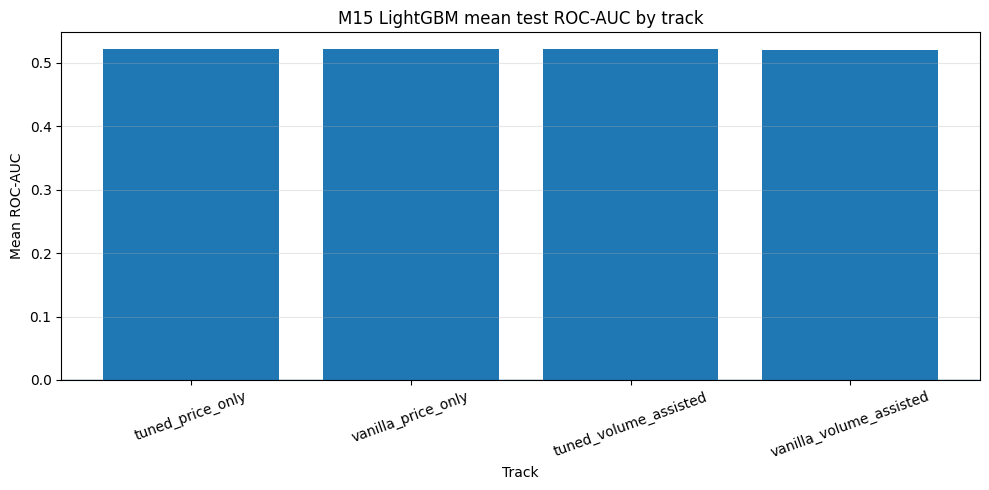

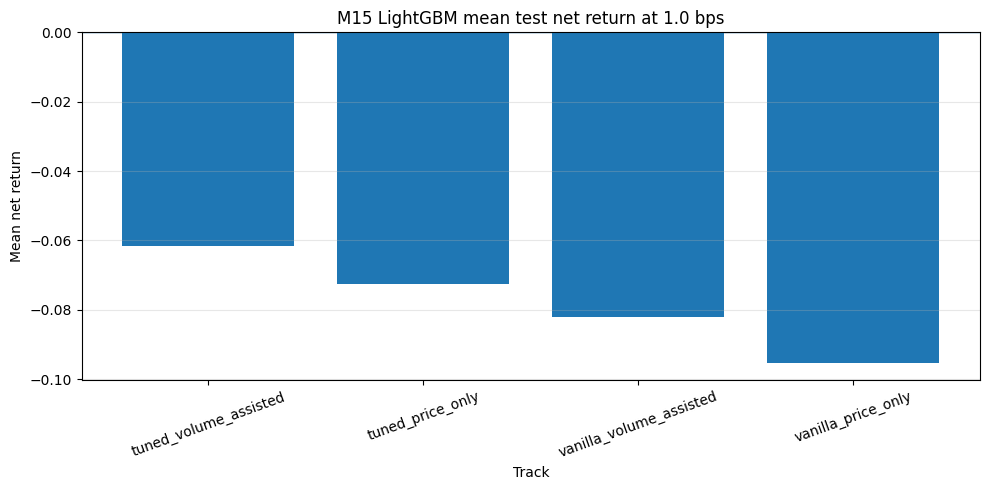

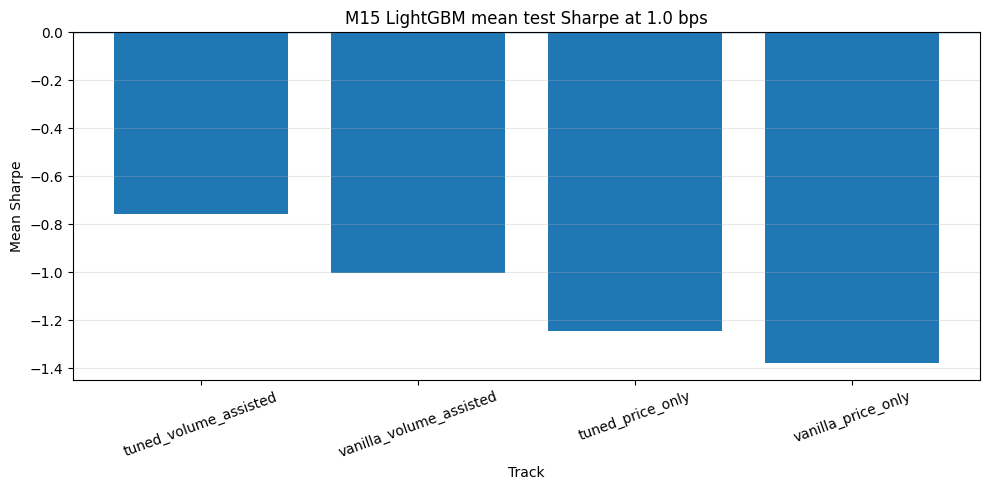

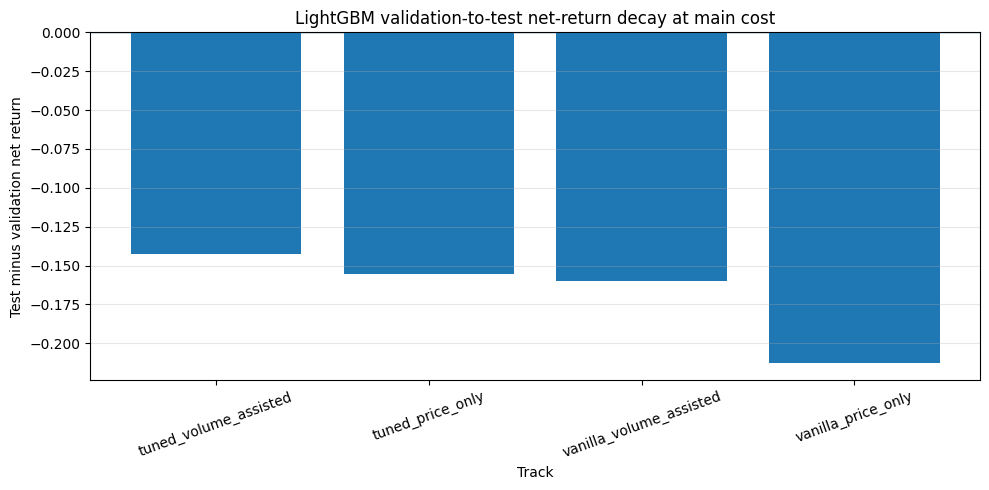

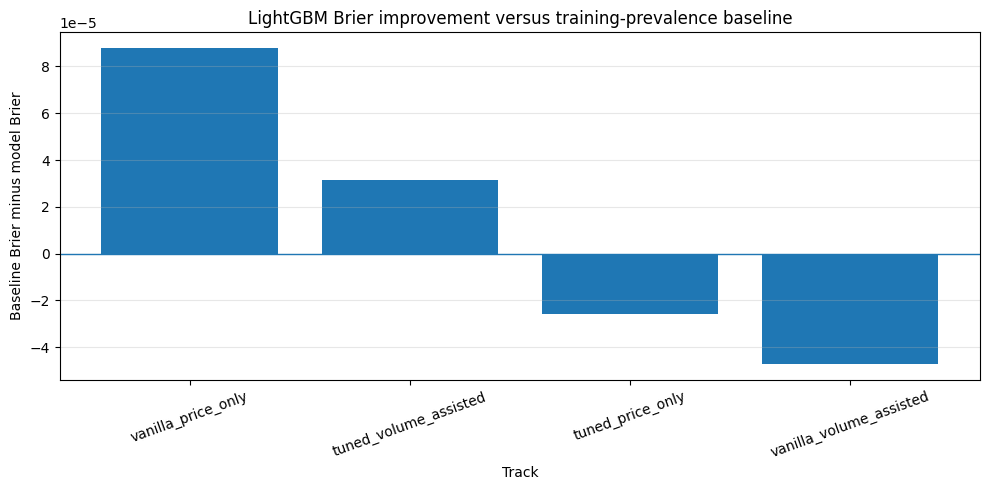

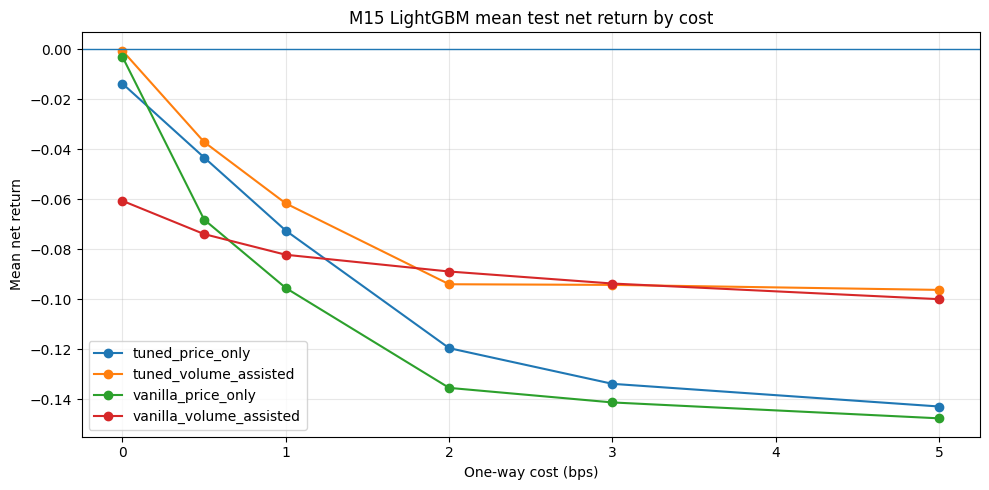

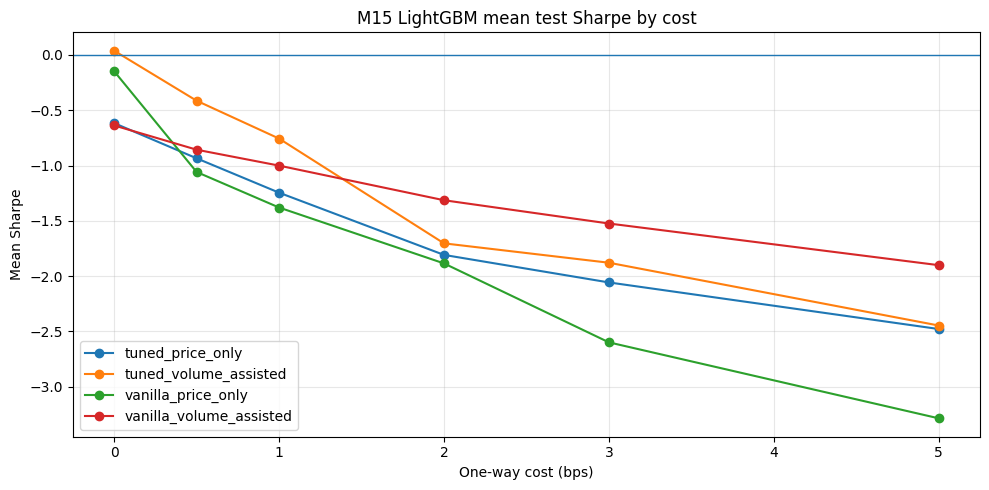

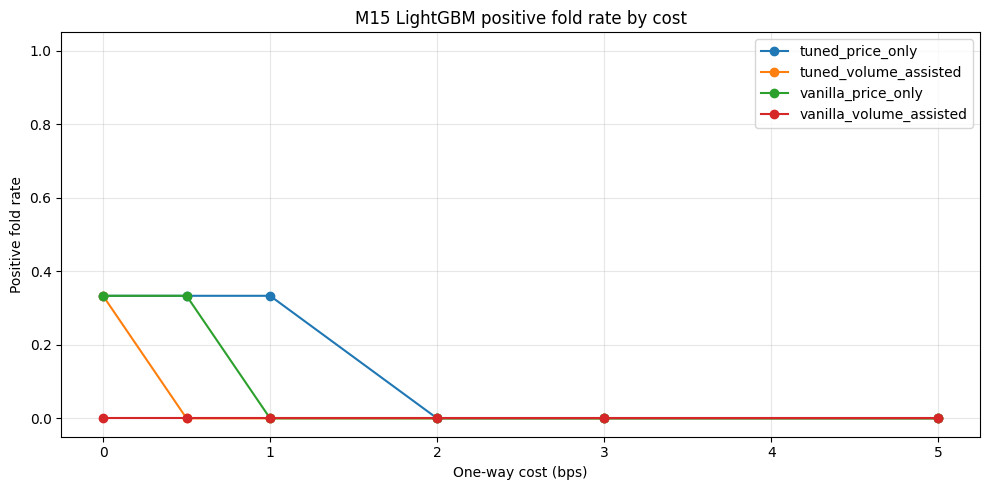

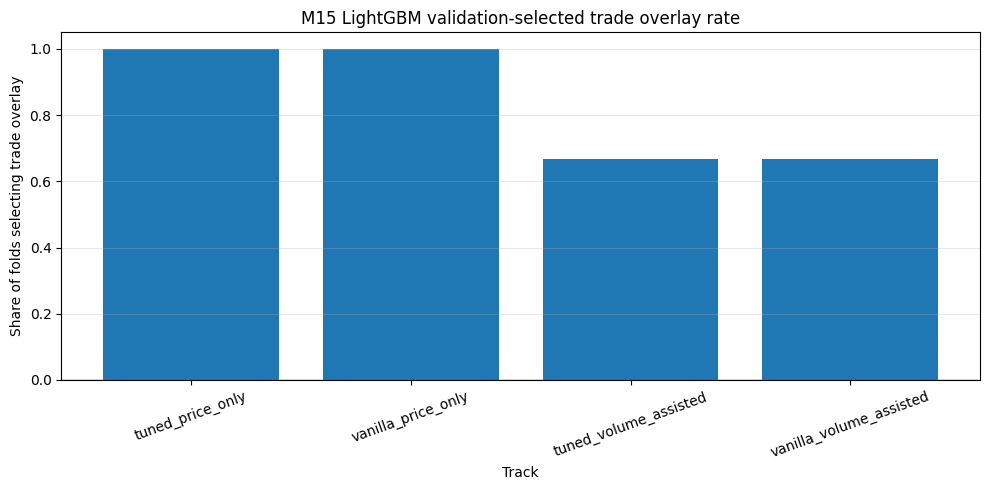

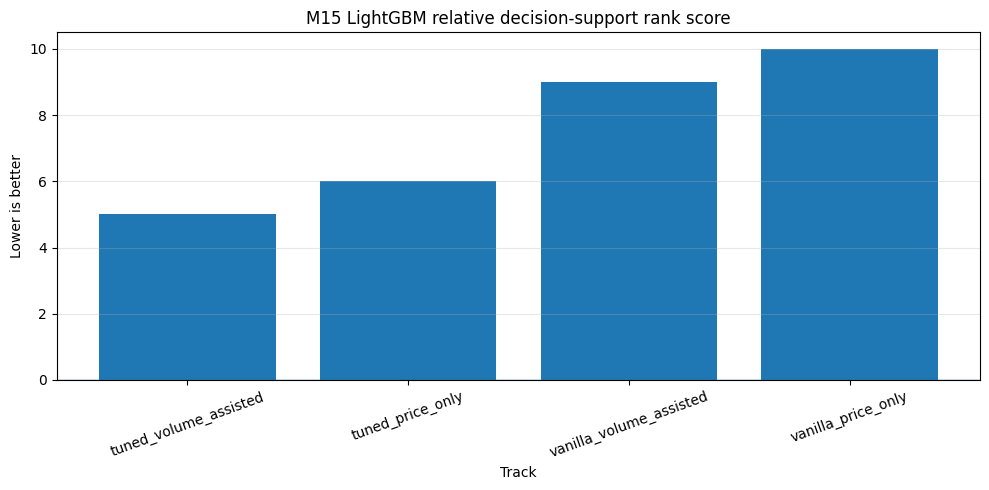

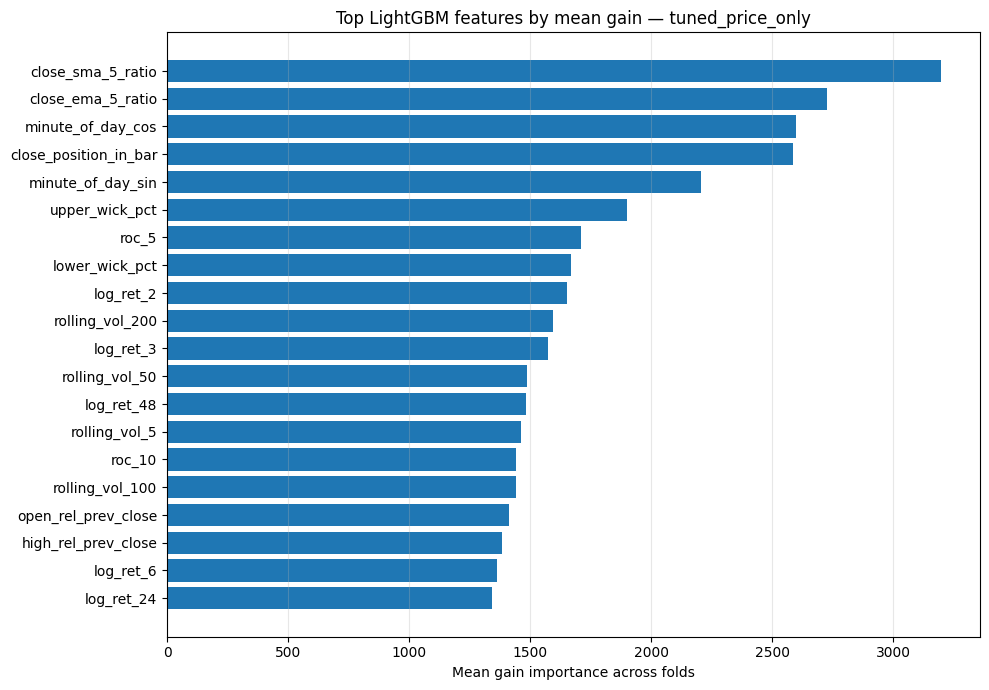

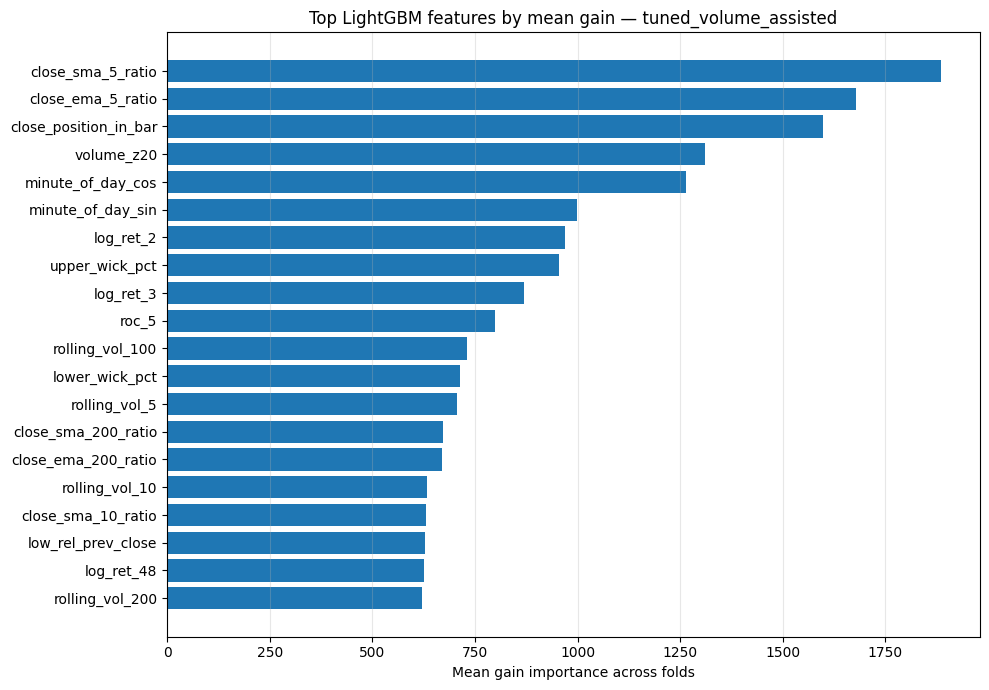

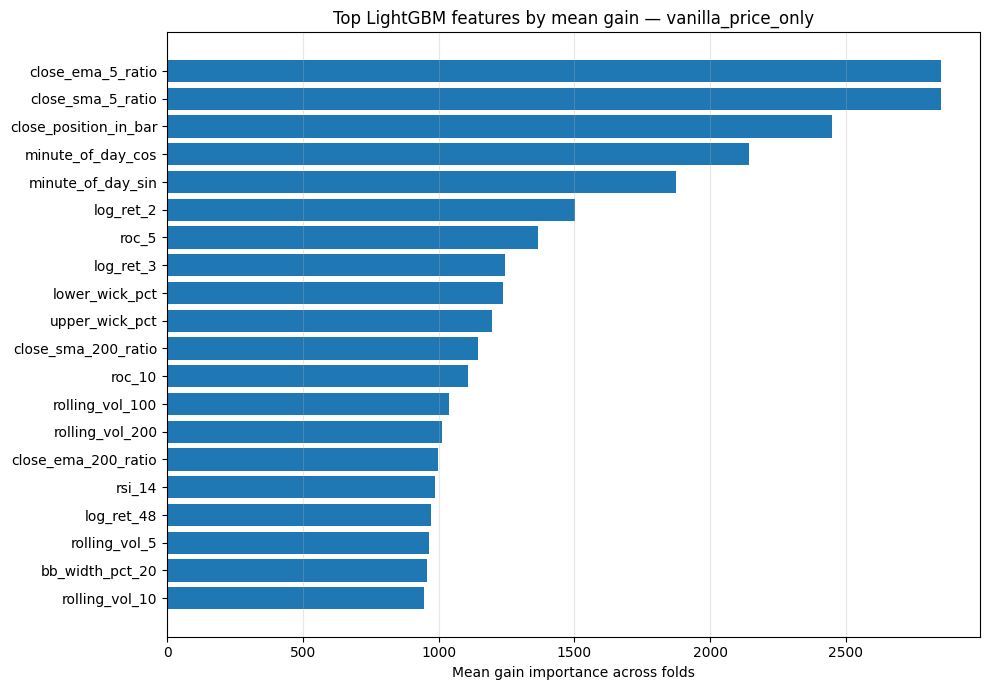

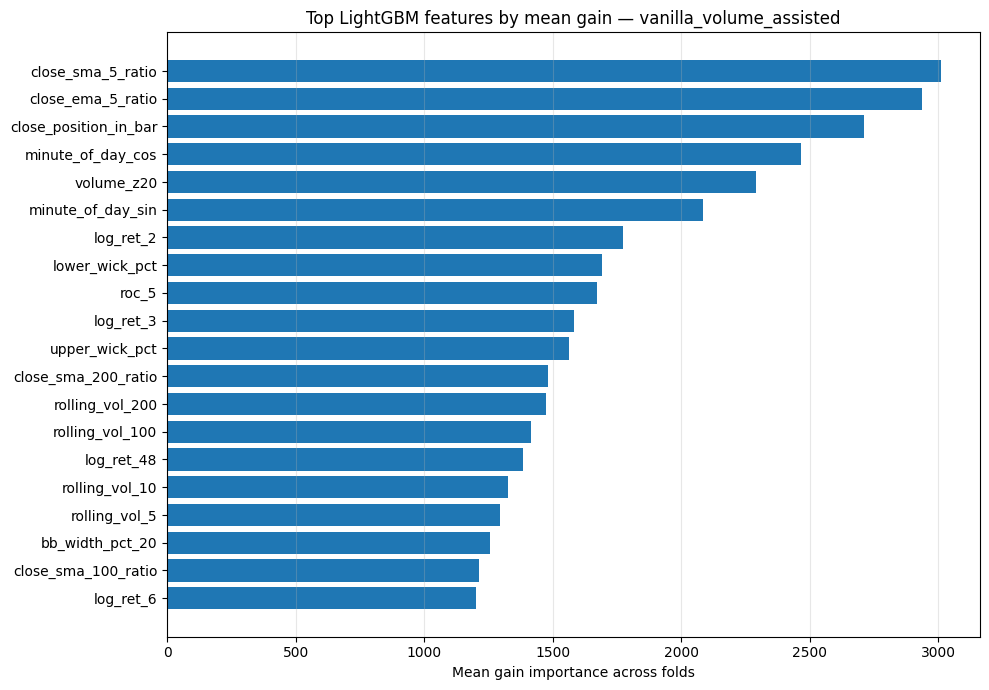

In [12]:
def save_bar(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, filename: str, rotation: int = 20):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(df[x].astype(str), df[y])
    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Track')
    ax.tick_params(axis='x', rotation=rotation)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160)
    plt.show()

save_bar(track_summary.sort_values('mean_roc_auc', ascending=False), 'track', 'mean_roc_auc', 'M15 LightGBM mean test ROC-AUC by track', 'Mean ROC-AUC', 'm15_lightgbm_harmonised_roc_auc_by_track.png')
save_bar(track_summary.sort_values('mean_net_return', ascending=False), 'track', 'mean_net_return', f'M15 LightGBM mean test net return at {MAIN_SELECTION_COST_BPS} bps', 'Mean net return', 'm15_lightgbm_harmonised_net_return_main_cost_by_track.png')
save_bar(track_summary.sort_values('mean_sharpe', ascending=False), 'track', 'mean_sharpe', f'M15 LightGBM mean test Sharpe at {MAIN_SELECTION_COST_BPS} bps', 'Mean Sharpe', 'm15_lightgbm_harmonised_sharpe_main_cost_by_track.png')
save_bar(decay_summary.sort_values('mean_net_return_decay', ascending=False), 'track', 'mean_net_return_decay', 'LightGBM validation-to-test net-return decay at main cost', 'Test minus validation net return', 'm15_lightgbm_harmonised_validation_to_test_decay.png')
save_bar(calibration_summary.sort_values('mean_brier_improvement_vs_baseline', ascending=False), 'track', 'mean_brier_improvement_vs_baseline', 'LightGBM Brier improvement versus training-prevalence baseline', 'Baseline Brier minus model Brier', 'm15_lightgbm_harmonised_brier_improvement.png')

fig, ax = plt.subplots(figsize=(10, 5))
for track in aggregate_trading['track'].unique():
    subset = aggregate_trading[aggregate_trading['track'] == track].sort_values('cost_bps')
    ax.plot(subset['cost_bps'], subset['mean_net_return'], marker='o', label=track)
ax.axhline(0, linewidth=1)
ax.set_title('M15 LightGBM mean test net return by cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Mean net return')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'm15_lightgbm_harmonised_net_return_by_cost.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for track in aggregate_trading['track'].unique():
    subset = aggregate_trading[aggregate_trading['track'] == track].sort_values('cost_bps')
    ax.plot(subset['cost_bps'], subset['mean_sharpe'], marker='o', label=track)
ax.axhline(0, linewidth=1)
ax.set_title('M15 LightGBM mean test Sharpe by cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Mean Sharpe')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'm15_lightgbm_harmonised_sharpe_by_cost.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for track in aggregate_trading['track'].unique():
    subset = aggregate_trading[aggregate_trading['track'] == track].sort_values('cost_bps')
    ax.plot(subset['cost_bps'], subset['positive_fold_rate'], marker='o', label=track)
ax.set_title('M15 LightGBM positive fold rate by cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Positive fold rate')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'm15_lightgbm_harmonised_positive_fold_rate_by_cost.png', dpi=160)
plt.show()

save_bar(overlay_summary.sort_values('selected_trade_rate', ascending=False), 'track', 'selected_trade_rate', 'M15 LightGBM validation-selected trade overlay rate', 'Share of folds selecting trade overlay', 'm15_lightgbm_harmonised_overlay_selected_trade_rate.png')
save_bar(track_summary.sort_values('simple_rank_score'), 'track', 'simple_rank_score', 'M15 LightGBM relative decision-support rank score', 'Lower is better', 'm15_lightgbm_harmonised_track_score.png')

for track in top20['track'].unique():
    subset = top20[top20['track'] == track].sort_values('mean_gain_importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(subset['feature'], subset['mean_gain_importance'])
    ax.set_title(f'Top LightGBM features by mean gain — {track}')
    ax.set_xlabel('Mean gain importance across folds')
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'top_features_{track}.png', dpi=160)
    plt.show()


## 9. Findings draft

The draft separates the best risk-gated system from the best active system so a zero-return all-stay-flat configuration is not mistaken for a profitable model.


In [13]:
risk_gated_best = track_summary.iloc[0]
active_candidates = track_summary[track_summary['selected_trade_rate'] > 0].sort_values(
    ['mean_net_return', 'mean_sharpe', 'mean_roc_auc'], ascending=[False, False, False]
)
active_best = active_candidates.iloc[0] if not active_candidates.empty else None
best_auc = track_summary.sort_values('mean_roc_auc', ascending=False).iloc[0]
positive_tracks = track_summary[track_summary['mean_net_return'] > 0]

lines = [
    'Notebook 3 — Harmonised M15 LightGBM full walk-forward evaluation findings draft',
    '=' * 90,
    '',
    f"Best risk-gated relative track at {MAIN_SELECTION_COST_BPS} bps: {risk_gated_best['track']}",
    f"  Mean ROC-AUC: {risk_gated_best['mean_roc_auc']:.6f}",
    f"  Mean net return: {risk_gated_best['mean_net_return']:.6f}",
    f"  Mean Sharpe: {risk_gated_best['mean_sharpe']:.6f}",
    f"  Selected trade rate: {risk_gated_best['selected_trade_rate']:.3f}",
    '',
]
if active_best is not None:
    lines.extend([
        f"Best active track at {MAIN_SELECTION_COST_BPS} bps: {active_best['track']}",
        f"  Mean net return: {active_best['mean_net_return']:.6f}",
        f"  Mean Sharpe: {active_best['mean_sharpe']:.6f}",
        f"  Positive fold rate: {active_best['positive_fold_rate']:.3f}",
        '',
    ])
lines.extend([
    f"Best classification track: {best_auc['track']} with mean ROC-AUC {best_auc['mean_roc_auc']:.6f}.",
    '',
])
if positive_tracks.empty:
    lines.append(f'At {MAIN_SELECTION_COST_BPS} bps, no LightGBM track achieved positive mean net return across folds.')
else:
    lines.append(f"At {MAIN_SELECTION_COST_BPS} bps, positive mean-net-return tracks: {', '.join(positive_tracks['track'])}.")
lines.extend([
    '',
    'Methodological interpretation:',
    '- LightGBM hyperparameters and boosting iterations were selected on an inner chronological validation year.',
    '- The outer validation year was reserved for overlay selection.',
    '- The test year was evaluated once after the model and overlay were frozen.',
    '- Persistent Optuna studies and configuration fingerprinting supported reproducible resume behaviour.',
    '- The final 2025–2026 holdout remained untouched.',
    '',
    'Critical note:',
    'A stronger inner validation AUC is not sufficient evidence of a trading edge. Transaction-cost survival, active fold coverage, fold consistency, drawdown, calibration and validation-to-test decay remain decisive.',
])

findings_path = OUTPUT_DIR / 'm15_lightgbm_harmonised_full_findings_draft.txt'
findings_path.write_text('\n'.join(lines), encoding='utf-8')
print(findings_path.read_text(encoding='utf-8'))


Notebook 3 — Harmonised M15 LightGBM full walk-forward evaluation findings draft

Best risk-gated relative track at 1.0 bps: tuned_volume_assisted
  Mean ROC-AUC: 0.521729
  Mean net return: -0.061695
  Mean Sharpe: -0.756453
  Selected trade rate: 0.667

Best active track at 1.0 bps: tuned_volume_assisted
  Mean net return: -0.061695
  Mean Sharpe: -0.756453
  Positive fold rate: 0.000

Best classification track: tuned_price_only with mean ROC-AUC 0.521846.

At 1.0 bps, no LightGBM track achieved positive mean net return across folds.

Methodological interpretation:
- LightGBM hyperparameters and boosting iterations were selected on an inner chronological validation year.
- The outer validation year was reserved for overlay selection.
- The test year was evaluated once after the model and overlay were frozen.
- Persistent Optuna studies and configuration fingerprinting supported reproducible resume behaviour.
- The final 2025–2026 holdout remained untouched.

Critical note:
A stronger

## 10. Output inventory


In [14]:
print('Tables:')
for path in sorted(TABLE_DIR.glob('*.csv')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nOptuna study artefacts:')
for path in sorted(OPTUNA_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nModels:')
for path in sorted(MODEL_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nPreprocessing/metadata artefacts:')
for path in sorted(PREPROCESSING_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nConfiguration:')
for path in sorted(CONFIG_DIR.glob('*')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nFigures:')
for path in sorted(FIGURE_DIR.glob('*.png')):
    print(' -', path.relative_to(OUTPUT_DIR))
print('\nFindings draft:')
print(' -', (OUTPUT_DIR / 'm15_lightgbm_harmonised_full_findings_draft.txt').relative_to(OUTPUT_DIR))


Tables:
 - tables/aggregate_test_classification_summary.csv
 - tables/aggregate_test_trading_summary_by_cost.csv
 - tables/calibration_baseline_comparison.csv
 - tables/classification_validation_to_test_decay_by_fold.csv
 - tables/feature_importance_by_fold.csv
 - tables/feature_importance_summary.csv
 - tables/fold_rows_m15_lightgbm.csv
 - tables/lightgbm_classification_metrics_by_fold.csv
 - tables/lightgbm_iteration_histories.csv
 - tables/lightgbm_training_log.csv
 - tables/overlay_viability_summary_at_main_cost.csv
 - tables/price_vs_volume_delta_summary_at_main_cost.csv
 - tables/selected_overlay_by_fold.csv
 - tables/temporal_role_summary.csv
 - tables/test_predictions_by_track_fold.csv
 - tables/test_trading_metrics_by_fold_cost.csv
 - tables/top_20_features_by_gain.csv
 - tables/track_summary_at_main_cost.csv
 - tables/tuning_study_summary.csv
 - tables/validation_overlay_grid_metrics_at_main_cost.csv
 - tables/validation_to_test_decay_by_fold_at_main_cost.csv
 - tables/valida